In [30]:
path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import HARP_and_age as haa
import nustar_utilities as nuutil
import lightcurves as lc
import visualize_dem_results as viz
import all_nu_analysis as ana

import pickle
import importlib

import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
import matplotlib.dates as mdates

from astropy.visualization import quantity_support
quantity_support()

with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
    all_targets = pickle.load(f)


def mod_timestring(timestring):
    modts=(':').join(timestring.split('-'))
    modts=('-').join(modts.split('_'))
    return modts


lw=3

First, are there differences between any of the results (or are the uncertainties wide enough that they are ALL mutually consistent)?

Using the metric of the integrals over certain EM thresholds.

In [2]:
with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
grf = data['ghost ray flags']

filelist = ana.get_same_region_file_lists(samesames, all_targets)

In [3]:
for ff in range(0, len(filelist)):
    print(samesames[ff], ' – ', len(filelist[ff]))

['01-nov-14_1 region_0']  –  2
['01-nov-14_1 region_1']  –  1
['11-dec-14 region_0']  –  1
['19-feb-16 region_0']  –  6
['22-apr-16_2 region_0']  –  6
['27-jul-16_1 region_0', '26-jul-16_1 region_0']  –  5
['26-jul-16_1 region_1']  –  1
['10-oct-17 region_0']  –  3
['10-oct-17 region_1']  –  2
['29-may-18_1 region_0']  –  24
['29-may-18_2 region_0']  –  1
['07-sep-18 region_0']  –  5
['10-sep-18 region_0', '09-sep-18 region_0']  –  14
['13-apr-19 region_0', '12-apr-19 region_0']  –  57
['29-jan-20 region_0']  –  5
['30-jan-20 region_0']  –  2
['08-jun-20 region_0', '07-jun-20 region_0', '06-jun-20 region_0']  –  18
['08-jan-21 region_0']  –  4
['14-jan-21 region_0']  –  3
['20-jan-21 region_0']  –  1
['29-apr-21 region_0']  –  9
['03-may-21_1 region_0']  –  5
['03-may-21_2 region_0']  –  3
['20-jul-21 region_0']  –  11
['20-jul-21 region_1']  –  40
['30-jul-21_1 region_0']  –  1
['30-jul-21_1 region_1']  –  1
['30-jul-21_2 region_0']  –  1
['17-nov-21_1 region_0']  –  1
['22-nov-21_1 r

In [4]:
#How many total quiescent files are there
allfiles = [item for sublist in filelist for item in sublist]
print(len(allfiles))
print('Potential combinations:', (len(allfiles)*(len(allfiles))-1))
print('Ordered potential combinations:', int((len(allfiles)*(len(allfiles))-1)/2))

248
Potential combinations: 61503
Ordered potential combinations: 30751


Further look at the behavior of regions over time. There are three cases to consider:

- Some regions have only one quiescent interval
- Some regions have one contiguous quiescent time, composed of more than one individual interval
- Some regions have more than one contiguous quiescent time

The first is not interesting for these purposes. Let's separate out the others:

In [5]:
with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
grf = data['ghost ray flags']
ss_times = ana.get_same_region_file_lists(samesames, all_targets, return_times=True)

only_one_time = []
contiguous_cases = []
time_gaps = []

for ss in range(0, len(ss_times)):
    contiguous, intervals, int_inds = ana.check_contig(ss_times[ss])
    #print(samesames[ss], contiguous)
    if contiguous:
        if len(ss_times[ss]) == 1:
            only_one_time.append(samesames[ss])
        else:
            contiguous_cases.append(samesames[ss])
    else:
        time_gaps.append(samesames[ss])


print('Only One: ', len(only_one_time), only_one_time)
print('')
print('One Contiguous: ', len(contiguous_cases), contiguous_cases)
print('')
print('Multi: ', len(time_gaps), time_gaps)

Only One:  10 [['01-nov-14_1 region_1'], ['11-dec-14 region_0'], ['26-jul-16_1 region_1'], ['29-may-18_2 region_0'], ['20-jan-21 region_0'], ['30-jul-21_1 region_0'], ['30-jul-21_1 region_1'], ['30-jul-21_2 region_0'], ['17-nov-21_1 region_0'], ['03-jun-22_2 region_1']]

One Contiguous:  4 [['01-nov-14_1 region_0'], ['08-jan-21 region_0'], ['03-may-21_1 region_0'], ['11-dec-22_2 region_0']]

Multi:  19 [['19-feb-16 region_0'], ['22-apr-16_2 region_0'], ['27-jul-16_1 region_0', '26-jul-16_1 region_0'], ['10-oct-17 region_0'], ['10-oct-17 region_1'], ['29-may-18_1 region_0'], ['07-sep-18 region_0'], ['10-sep-18 region_0', '09-sep-18 region_0'], ['13-apr-19 region_0', '12-apr-19 region_0'], ['29-jan-20 region_0'], ['30-jan-20 region_0'], ['08-jun-20 region_0', '07-jun-20 region_0', '06-jun-20 region_0'], ['14-jan-21 region_0'], ['29-apr-21 region_0'], ['03-may-21_2 region_0'], ['20-jul-21 region_0'], ['20-jul-21 region_1'], ['22-nov-21_1 region_0', '21-nov-21 region_0', '20-nov-21 region_

Some of these are globally consistent, and others not. Let's continue to examine in further detail. 

In [8]:
time_gaps

[['19-feb-16 region_0'],
 ['22-apr-16_2 region_0'],
 ['27-jul-16_1 region_0', '26-jul-16_1 region_0'],
 ['10-oct-17 region_0'],
 ['10-oct-17 region_1'],
 ['29-may-18_1 region_0'],
 ['07-sep-18 region_0'],
 ['10-sep-18 region_0', '09-sep-18 region_0'],
 ['13-apr-19 region_0', '12-apr-19 region_0'],
 ['29-jan-20 region_0'],
 ['30-jan-20 region_0'],
 ['08-jun-20 region_0', '07-jun-20 region_0', '06-jun-20 region_0'],
 ['14-jan-21 region_0'],
 ['29-apr-21 region_0'],
 ['03-may-21_2 region_0'],
 ['20-jul-21 region_0'],
 ['20-jul-21 region_1'],
 ['22-nov-21_1 region_0',
  '21-nov-21 region_0',
  '20-nov-21 region_0',
  '19-nov-21 region_0'],
 ['03-jun-22_2 region_0']]

In [6]:
# def make_clean_incons(incons_pairs):
#     #Sort time interval pairs to be in time order
#     incons_pairs_sorted = [ip.sort() for ip in incons_pairs]

#     counter=0
#     #Remove duplicates
#     checked=[]
#     for ip in incons_pairs:
#         ipc=False
#         for c in checked:
#             if ip[0] == c[0] and ip[1] == c[1]:
#                 ipc=True
                
#         if not ipc:
#             checked.append(ip)
            
#         if counter % 1000 == 0:
#             print(counter)
#         counter+=1
        

#     return checked

def make_clean_incons(incons_pairs):
    #Sort time interval pairs to be in time order
    #[ip.sort() for ip in incons_pairs]

    repeats=[]
    
    counter=0
    #Remove duplicates
    checked=[]
    for ip in incons_pairs:
        ipc=False
        for c in checked:
            #print(c)
            #print(ip)
            if ip[0] == c[0] and ip[1] == c[1]:
                ipc=True
                repeats.append(ip)
                print(counter)
                print(ip, c)
                print('')
                
        if not ipc:
            checked.append(ip)
            
        if counter % 1000 == 0:
            print(counter)
        counter+=1
        

    return checked



def get_intermediate_goesmaxes(timepairs, input_ax=[]):
    importlib.reload(lc)
    from datetime import timedelta
    import matplotlib.dates as mdates
    labelfontsize=10

    goesmax=[]
    for icp in timepairs:
        tr=[icp[0].datetime, icp[1].datetime]
        print(tr[0].strftime('%H-%M-%S'), tr[1].strftime('%H-%M-%S'))
        #from datetime import timezone
        #tr = [t.replace(tzinfo=timezone.utc) for t in tr_]
        goes_number = 15
        if tr[0].year > 2016:
            goes_number = 16
    
        lc.get_goes(tr, satellite=goes_number)
        instrument='GOES'
        gdata = lc.load_lightcurves(instrument)
        
        ylabel = gdata['GOES flux label']
        goestimes = gdata['GOES Times']
        xrsbcounts = lc.boxcar_average(gdata['XRSB counts'], 10)
        xrsblabel = gdata['XRSB label']
        gts = [t.datetime for t in goestimes]
        print('goesstep: ', gts[2]-gts[1])
        
        if input_ax:
            axg=input_ax
        else:
            fig, axg = plt.subplots(1, 1, figsize=(6,4))
        #xrs=[x.value for x in all_xrsb]
        axg.plot(gts, xrsbcounts, label='GOES '+xrsblabel, color='red')
        axg.set_yscale('log')
        #axg.set_ylim([1e-7,1e-6])
        axg.yaxis.set_ticks([1e-7, 1e-6, 1e-5, 1e-4], labels=['B', 'C','M','X'], color='red', fontsize=labelfontsize)
        axg.grid(True, which='major', axis='y', linestyle=':', color='red')
        axg.axvline(tr[0])
        axg.axvline(tr[1])
        axg.set_xlim([tr[0]-timedelta(hours=1), tr[1]+timedelta(hours=1)])
    
        intergoes = np.where(np.logical_and(tr[0] < np.array(gts), np.array(gts) < tr[1]))[0]
        #axg.plot(np.array(gts)[intergoes], xrsbcounts[intergoes], label='GOES '+xrsblabel, color='blue')
        maxind = np.where(xrsbcounts[intergoes] == np.nanmax(xrsbcounts[intergoes]))[0]
        print(np.nanmax(xrsbcounts[intergoes]))
        print(maxind)
        maxval = xrsbcounts[intergoes][maxind]
        if len(maxval) > 1:
            maxval=maxval[0]
        maxtime = np.array(gts)[intergoes][maxind]
        for m in maxtime:
            axg.axvline(m, color='blue')
        goesmax.append(maxval)
        axg.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    return goesmax

New method: rather than using the EM thresholds, want to compare the actual DEM distributions directly. 

In [7]:
filelist = ana.get_same_region_file_lists(time_gaps, all_targets)

all_durs_demcomp=[]
noncons_durs_demcomp=[]
cons_durs_demcomp=[]

incons_filepairs=[]
incons_times = []
incons_full_times = []
incons_regions = []
cons_times = []
all_times = []
for fi in range(0, len(filelist)):
    ff=filelist[fi]
    any=False
    ff.sort()
    dems=[]
    edems1=[]
    edems2=[]
    times=[]
    for f_ in ff:
        #print(f_)
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        dems.append(np.array(data['DEM']))
        edems1.append(np.array(data['edem'][0]))
        edems2.append(np.array(data['edem'][1]))
        times.append(data['time_interval'])

    lower = np.array(dems)-np.array(edems1)
    upper = np.array(dems)+np.array(edems2)
    #print(ff[0])
    #Initial check: is there any instance where the upper bound at any time in a given temp bin 
    #is lower than the lower bound at any other time?
    if np.any(np.max(lower, axis=0) > np.min(upper, axis=0)):
        #If so, we go for details:
            for f1 in range(0, len(ff)):
                for f2 in range(0, len(ff)):
                    diff = lower[f1]-upper[f2]
                    if np.any(diff > 0):
                        #print(f1, f2)#, diff)
                        incons_filepairs.append([ff[f1], ff[f2]])
                        incons_times.append([times[f1][0], times[f2][0]])
                        incons_regions.append(time_gaps[fi])
                        any=True
    else:
        cons_times.append([times[0][0], times[-1][1]])
        

    all_times.append([times[0][0], times[-1][1]])
        
    print('')  
    all_durs_demcomp.append(np.max(times)-np.min(times)) 
    if any:
        #print((np.max(times)-np.min(times)).to(u.h), times[0][0])
        noncons_durs_demcomp.append(np.max(times)-np.min(times))
        incons_full_times.append([times[0][0], times[-1][1]])
    else:
        cons_durs_demcomp.append(np.max(times)-np.min(times))
        print((np.max(times)-np.min(times)).to(u.h), times[0][0])



3.623611111111112 h 2016-04-22 18:47:45


2.3361111111111104 h 2017-10-10 03:21:15

2.3361111111111104 h 2017-10-10 03:21:15





8.201388888888891 h 2020-01-29 11:12:35

5.300277777777777 h 2020-01-30 13:31:40


3.9708333333333345 h 2021-01-14 09:34:20


3.5375000000000014 h 2021-05-03 18:45:10

5.786111111111109 h 2021-07-20 02:52:00


50.21527777777777 h 2021-11-19 22:37:15

3.948611111111112 h 2022-06-03 18:36:35


Now, instead of checking for inconsistency across regions, check for inconsistency across contiguous observations (there should not be if our quiescence analysis is well motivated!). We see that there are not. 

In [8]:
filelist = ana.get_same_region_file_lists(time_gaps, all_targets)


for fi in range(0, len(filelist)):
    ff=filelist[fi]
    any=False
    ff.sort()
    dems=[]
    edems1=[]
    edems2=[]
    times=[]
    for f_ in ff:
        #print(f_)
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        dems.append(np.array(data['DEM']))
        edems1.append(np.array(data['edem'][0]))
        edems2.append(np.array(data['edem'][1]))
        times.append(data['time_interval'])

    contiguous, intervals, int_inds = ana.check_contig(times)
    if times:
        region_int_above10s_=[]
        for ii in int_inds:
            #print(ii)
            indx = np.arange(ii[0],ii[1])
            dems_ = np.array(dems)[indx]
            edems1_ = np.array(edems1)[indx]
            edems2_ = np.array(edems2)[indx]

            lower = np.array(dems_)-np.array(edems1_)
            upper = np.array(dems_)+np.array(edems2_)

            #Initial check: is there any instance where the upper bound at any time in a given temp bin 
            #is lower than the lower bound at any other time?
            if np.any(np.max(lower, axis=0) > np.min(upper, axis=0)):
                print('AHHHHHHHHHHHHHH')

We know that there are inconsistencies between results across different regions. Let's categorize those. 

In [9]:
filelist = ana.get_same_region_file_lists(samesames, all_targets)

demsall=[]
edemsall1=[]
edemsall2=[]
timesall=[]
lowersall=[]
uppersall=[]
for fi in range(0, len(filelist)):
    ff=filelist[fi]
    any=False
    ff.sort()
    dems=[]
    edems1=[]
    edems2=[]
    times=[]
    uppers=[]
    lowers=[]
    for f_ in ff:
        #print(f_)
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        ts=data['ts']
        dems.append(np.array(data['DEM']))
        edems1.append(np.array(data['edem'][0]))
        edems2.append(np.array(data['edem'][1]))
        times.append(data['time_interval'])
        #print(type(data['time_interval']))
        #print(f_)
        #print('')
        lowers.append(np.array(data['DEM'])-np.array(data['edem'][0]))
        uppers.append(np.array(data['DEM'])+np.array(data['edem'][1]))
        
    demsall.append(dems)
    edemsall1.append(edems1)
    edemsall2.append(edems1)
    timesall.append(times)
    lowersall.append(lowers)
    uppersall.append(uppers)


minimum_off=[]
low_temp_incons=[]
inconsistent_pairs=[]
inconsistent_times=[]
inconsistent_inds=[]
diffs=[]
alloptions=0

maxplots=0
countsdubs=0
difference_cases=0
dnotin=0
countsin=0

#For each region
for i in range(0, len(demsall)):
    #print(filelist[i][0].split('/')[6])
    #For each time in that region
    for d in range(0, len(demsall[i])):
        #For all the regions again
        for dd in range(0, len(demsall)):
            #For each time in that other region
            for ddd in range(0, len(demsall[dd])):
                lower = lowersall[i][d]
                lower2 = lowersall[dd][ddd]
                upper = uppersall[dd][ddd]
                upper2 = uppersall[i][d]
                diff = lower-upper
                diff2 = upper2-lower2
                alloptions+=1
                
                #If, anywhere in temperature, the lower bound of DEM1 is higher than the upper bound of DEM2
                #OR, anywhere in temperature, the upper bound of DEM1 is lower than the lower bound of DEM2:
                if np.any(diff > 0) or np.any(diff2 < 0):
                    difference_cases+=1
                    if [dd, ddd, i, d] not in inconsistent_inds:
                        dnotin+=1
                        inconsistent_inds.append([dd, ddd, i, d])
                        if [i,d,dd,ddd] not in inconsistent_inds:
                            diffs.append(np.where(diff > 0, 1, 0))
                        # if maxplots < 20:
                        #     fig = plt.figure(constrained_layout=True, figsize=(5,3))
                        #     plt.plot(ts, demsall[i][d]/np.max(demsall[i][d]))
                        #     plt.plot(ts, demsall[dd][ddd]/np.max(demsall[dd][ddd]))
                        #     plt.plot(ts, np.where(diff > 0, 1, 0))
                        #     maxplots+=1
                        
                        #    print([dd,ddd,i,d], '|', [i,d,dd, ddd])
                        #else:
                        #    if [i,d,dd,ddd] == [dd,ddd,i,d]:
                        #        print('same')
                        #diffs.append(np.array(diff))
                        
                        # ips = [timesall[i][d][0], timesall[dd][ddd][0]]
                        # ips.sort()
                        
                        # inthere=False
                        # for c in inconsistent_times:
                        #     if ips[0] == c[0] and ips[1] == c[1]:
                        #         inthere=True
                        # if not inthere:
                        #     inconsistent_times.append([timesall[i][d][0], timesall[dd][ddd][0]])
                        
                            inconsistent_times.append([timesall[i][d][0], timesall[dd][ddd][0]]) 
                            inconsistent_pairs.append([filelist[i][d], filelist[dd][ddd]])
                            #inconsistent_times.append([timesall[i][d][0], timesall[dd][ddd][0]])
                        if np.any(diff > 0):
                            minimum_off.append(np.array(ts)[np.where(diff > 0)[0][0]])
                            if np.array(ts)[np.where(diff > 0)[0][0]] < 6.2:
                                low_temp_incons.append([filelist[i][d], filelist[dd][ddd]])
                        if np.any(diff2 < 0):
                            minimum_off.append(np.array(ts)[np.where(diff2 < 0)[0][0]])
                            if np.array(ts)[np.where(diff2 < 0)[0][0]] < 6.2:
                                low_temp_incons.append([filelist[i][d], filelist[dd][ddd]])

diffs=np.array(diffs)    

print('All cases where there is a difference according to our condition: ', difference_cases)
print('Same as above, but also the indices are not yet in the list: ', dnotin)
print('Same as above, but inverse indices are also not yet in the list: ', len(diffs))
#print(len(inconsistent_times))

All cases where there is a difference according to our condition:  31896
Same as above, but also the indices are not yet in the list:  31896
Same as above, but inverse indices are also not yet in the list:  15948


In [10]:
citimes = make_clean_incons(inconsistent_pairs)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000


Text(0, 0.5, '$[cm^{-5}]$')

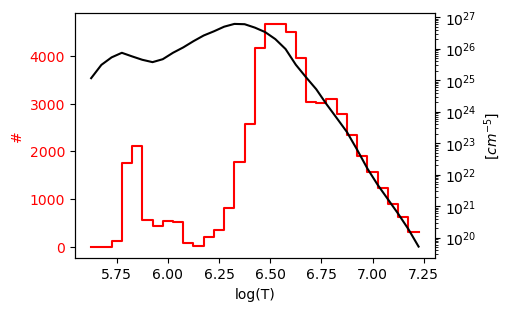

In [11]:
diff_dist = np.sum(diffs, axis=0)
fig, ax = plt.subplots(constrained_layout=True, figsize=(5,3))
ax.step(data['ts'],diff_dist, color='red')
ax.set_ylabel('#', color='red')
ax.tick_params(axis='y', labelcolor='red')
ax.set_xlabel('log(T)')

ax2=ax.twinx()
ax2.plot(data['ts'], data['DEM'], color='black')
ax2.set_yscale('log')
ax2.set_ylabel(r'$[cm^{-5}]$')

In [13]:
him='/Users/jmdunca2/do-dem/DEM_folders//initial_dem_7sep18//14-56-55_15-14-20/14-56-55_15-14-20_5.6_7.2_07-sep-18_MC_DEM_result_withparams.pickle'

for l in range(0, len(low_temp_incons)):
    lt=low_temp_incons[l]
    #print(lt[1])
    if lt[1] == him:
        print(l, lt)

380 ['/Users/jmdunca2/do-dem/DEM_folders//initial_dem_29may18_1//15-59-35_16-00-40/15-59-35_16-00-40_5.6_7.2_29-may-18_1_MC_DEM_result_withparams.pickle', '/Users/jmdunca2/do-dem/DEM_folders//initial_dem_7sep18//14-56-55_15-14-20/14-56-55_15-14-20_5.6_7.2_07-sep-18_MC_DEM_result_withparams.pickle']
417 ['/Users/jmdunca2/do-dem/DEM_folders//initial_dem_29may18_1//16-03-05_16-03-45/16-03-05_16-03-45_5.6_7.2_29-may-18_1_MC_DEM_result_withparams.pickle', '/Users/jmdunca2/do-dem/DEM_folders//initial_dem_7sep18//14-56-55_15-14-20/14-56-55_15-14-20_5.6_7.2_07-sep-18_MC_DEM_result_withparams.pickle']
456 ['/Users/jmdunca2/do-dem/DEM_folders//initial_dem_29may18_1//16-03-45_16-04-50/16-03-45_16-04-50_5.6_7.2_29-may-18_1_MC_DEM_result_withparams.pickle', '/Users/jmdunca2/do-dem/DEM_folders//initial_dem_7sep18//14-56-55_15-14-20/14-56-55_15-14-20_5.6_7.2_07-sep-18_MC_DEM_result_withparams.pickle']
490 ['/Users/jmdunca2/do-dem/DEM_folders//initial_dem_29may18_1//18-15-15_18-22-40/18-15-15_18-22-40

/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:239: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data1['ts_'],data1['dn_in'][i]/data1['trmatrix'][:,i],
/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:253: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data2['ts_'],data2['dn_in'][i]/data2['trmatrix'][:,i],
/var/folders/55/06y21cm93w70z_8gl7yxv2t40000gq/T/ipykernel_17734/3317589130.py:67: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  plt.savefig('very_incons_ex.png', dpi=300)
/var/folders/55/06y21cm93w70z_8gl7yxv2t40000gq/T/ipykernel_17734/3317589130.py:67: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  plt.savefig('very_incons_ex.png', dpi=300)
/var/folders/55/06y21cm93w70z_8gl7yxv2t40000gq/T/ipykernel_17734/3317589130.py:67: UserWarning: constraine

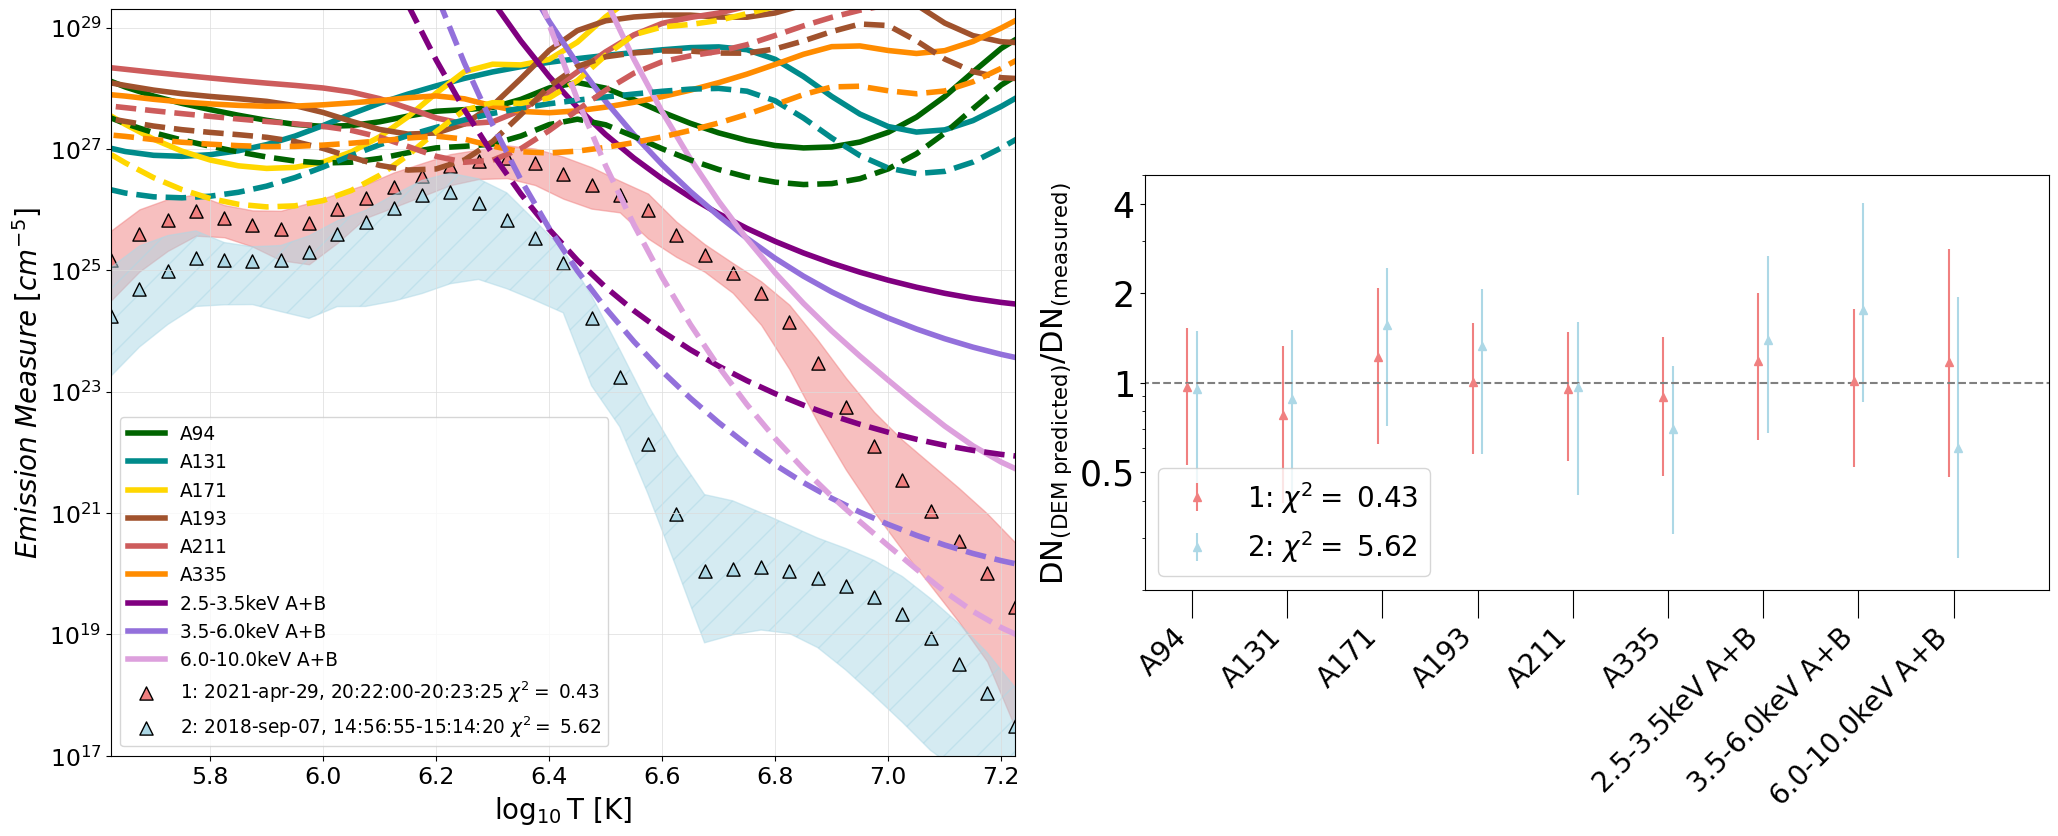

In [40]:
#Looking at cases where the solution inconsistency starts at lower temperatures.

len(low_temp_incons)

#Make comparison plots for all the inconsistent times:

importlib.reload(viz)

working_dir = '/Users/jmdunca2/do-dem/consistency_plots/'

labelfontsize=20

for pp in low_temp_incons[3872:3873]:
    data1, timestring1, time1 = viz.load_DEM(pp[0])
    data2, timestring2, time2 = viz.load_DEM(pp[1])
    namest=pp[0].split('/')[6][11:]
    namest2=pp[1].split('/')[6][11:]

    fig = plt.figure(constrained_layout=True, figsize=(25,14))
    gs = fig.add_gridspec(7, 6,  hspace=1, wspace=0.6)
    ax1 = fig.add_subplot(gs[0:5, 0:3])
    ax2 = fig.add_subplot(gs[1:4, 3:])
    #ax3 = fig.add_subplot(gs[5:, 1:5]) #, sharex=ax1)
    
    namest = '2021-apr-29'
    namest2 = '2018-sep-07'
    
    
    #namest = '2018-sep-09'
    #namest2 = '2018-sep-10'
    
    #data1['fill_color'] = 'green'
    #data2['fill_color'] = 'orange'
    importlib.reload(viz)


    viz.compare_DEMs(data1, data2, timestring1, timestring2, title1=namest+', '+mod_timestring(timestring1), 
                     title2=namest2+', '+mod_timestring(timestring2), 
                     plotMK=False, plot=True, working_dir=working_dir, input_ax=ax1, input_ax2=ax2)
    
    ax1.tick_params(axis='both', labelsize=17)
    #ax1.set_title('Comparison - Two Quiescent Times on '+namest, fontsize=labelfontsize)
    ax1.set_title('', fontsize=labelfontsize)
    ax1.set_xlabel(r'$\log_{10}$T [K]', fontsize=labelfontsize)
    ax1.set_ylim([1e17, 2e29])
    ax1.legend(ncols=1, fontsize=labelfontsize/1.5)

    #ax2.set_title('Residuals', fontsize=labelfontsize)
    ax2.set_title('', fontsize=labelfontsize)
    ax2.yaxis.get_label().set_fontsize(labelfontsize+2)
    ax2.tick_params(axis='x', labelsize=labelfontsize)
    ax2.set_ylim([0.2,5.])
    ax2.set_yticks([0.5,1,2,4], ['0.5','1','2', '4'], fontsize=25)
    ax2.legend(fontsize = 20, loc='lower left')



    # ax3.step(data['ts'], diff_dist, color='red', linewidth=2, label='Differences between \n all quiescent AR EMD solutions')
    # ax3.set_ylabel('# of cases', color='red', fontsize=labelfontsize)
    # ax3.tick_params(axis='y', labelcolor='red')
    # ax3.set_xlabel(r'$\log_{10}$T [K]', fontsize=labelfontsize)
    # ax3.legend(fontsize=labelfontsize)
    # ax3.axvline(6)
    # ax3.axvline(6.35)


    plt.savefig('very_incons_ex.png', dpi=300)

Example of the evolution of a single AR over a very ling time: AR12711 was observed on the limb on 2018 May 29, 7 days after it emerged on-disk. It was observed again on 2018 September 7 as a highly aged decaying region. 

/Users/jmdunca2/do-dem/DEM_folders//initial_dem_29may18_2/region_0//21-16-55_21-31-40/21-16-55_21-31-40_5.6_7.2_29-may-18_2_MC_DEM_result_withparams.pickle
/Users/jmdunca2/do-dem/DEM_folders//initial_dem_7sep18//14-56-55_15-14-20/14-56-55_15-14-20_5.6_7.2_07-sep-18_MC_DEM_result_withparams.pickle


/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:239: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data1['ts_'],data1['dn_in'][i]/data1['trmatrix'][:,i],
/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:253: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data2['ts_'],data2['dn_in'][i]/data2['trmatrix'][:,i],


/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


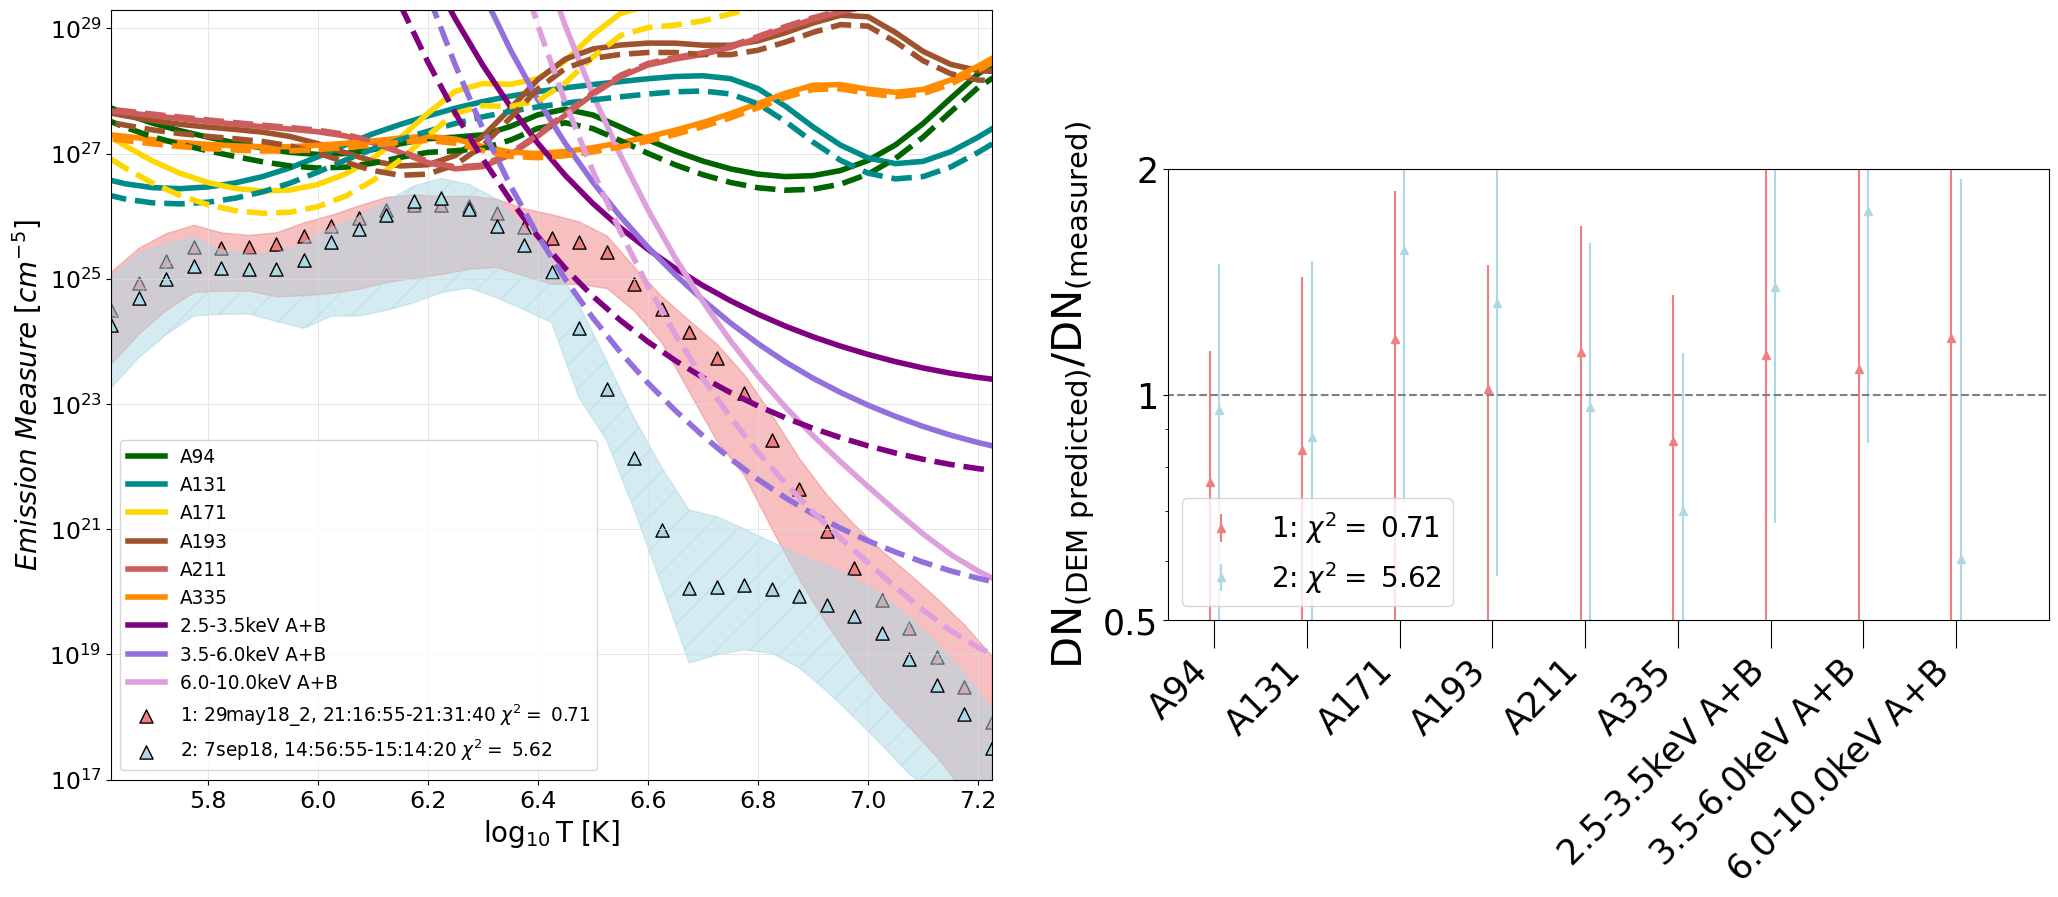

In [26]:
file1 = all_targets['29-may-18_2']['res_file_dict(s)'][0]['quiet files all-inst'][0]
file2 = all_targets['07-sep-18']['res_file_dict(s)'][0]['quiet files all-inst'][0]
print(file1)
print(file2)

fig = plt.figure(constrained_layout=True, figsize=(25,10))
gs = fig.add_gridspec(5, 2)
ax1 = fig.add_subplot(gs[0:5, 0])
ax2 = fig.add_subplot(gs[1:4, 1])


data1, timestring1, time1 = viz.load_DEM(file1)
data2, timestring2, time2 = viz.load_DEM(file2)
namest=file1.split('/')[6][12:]
namest2=file2.split('/')[6][12:]


#data1['fill_color'] = 'green'
#data2['fill_color'] = 'orange'
importlib.reload(viz)


viz.compare_DEMs(data1, data2, timestring1, timestring2, title1=namest+', '+mod_timestring(timestring1), 
                 title2=namest2+', '+mod_timestring(timestring2), 
                 plotMK=False, plot=True, working_dir=working_dir, input_ax=ax1, input_ax2=ax2)

ax1.tick_params(axis='both', labelsize=17)
#ax1.set_title('Comparison - Two Quiescent Times on '+namest, fontsize=labelfontsize)
ax1.set_title('', fontsize=labelfontsize)

#ax2.set_title('Residuals', fontsize=labelfontsize)
ax2.set_title('', fontsize=labelfontsize)
ax1.set_ylim([1e17, 2e29])
ax1.legend(ncols=1, fontsize=labelfontsize/1.5)


Another multiple observation case: AR12847 and AR12849 were observed on 20-jul-21 and also 30-jul-21:

/Users/jmdunca2/do-dem/DEM_folders//initial_dem_20jul21//south//02-52-00_03-01-15/02-52-00_03-01-15_5.6_7.2_20-jul-21_MC_DEM_result_withparams.pickle
/Users/jmdunca2/do-dem/DEM_folders//initial_dem_30jul21_1//east//21-18-20_22-18-50/21-18-20_22-18-50_5.6_7.2_30-jul-21_1_MC_DEM_result_withparams.pickle


/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:239: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data1['ts_'],data1['dn_in'][i]/data1['trmatrix'][:,i],
/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:253: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data2['ts_'],data2['dn_in'][i]/data2['trmatrix'][:,i],


/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  func(*args, **kwargs)
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


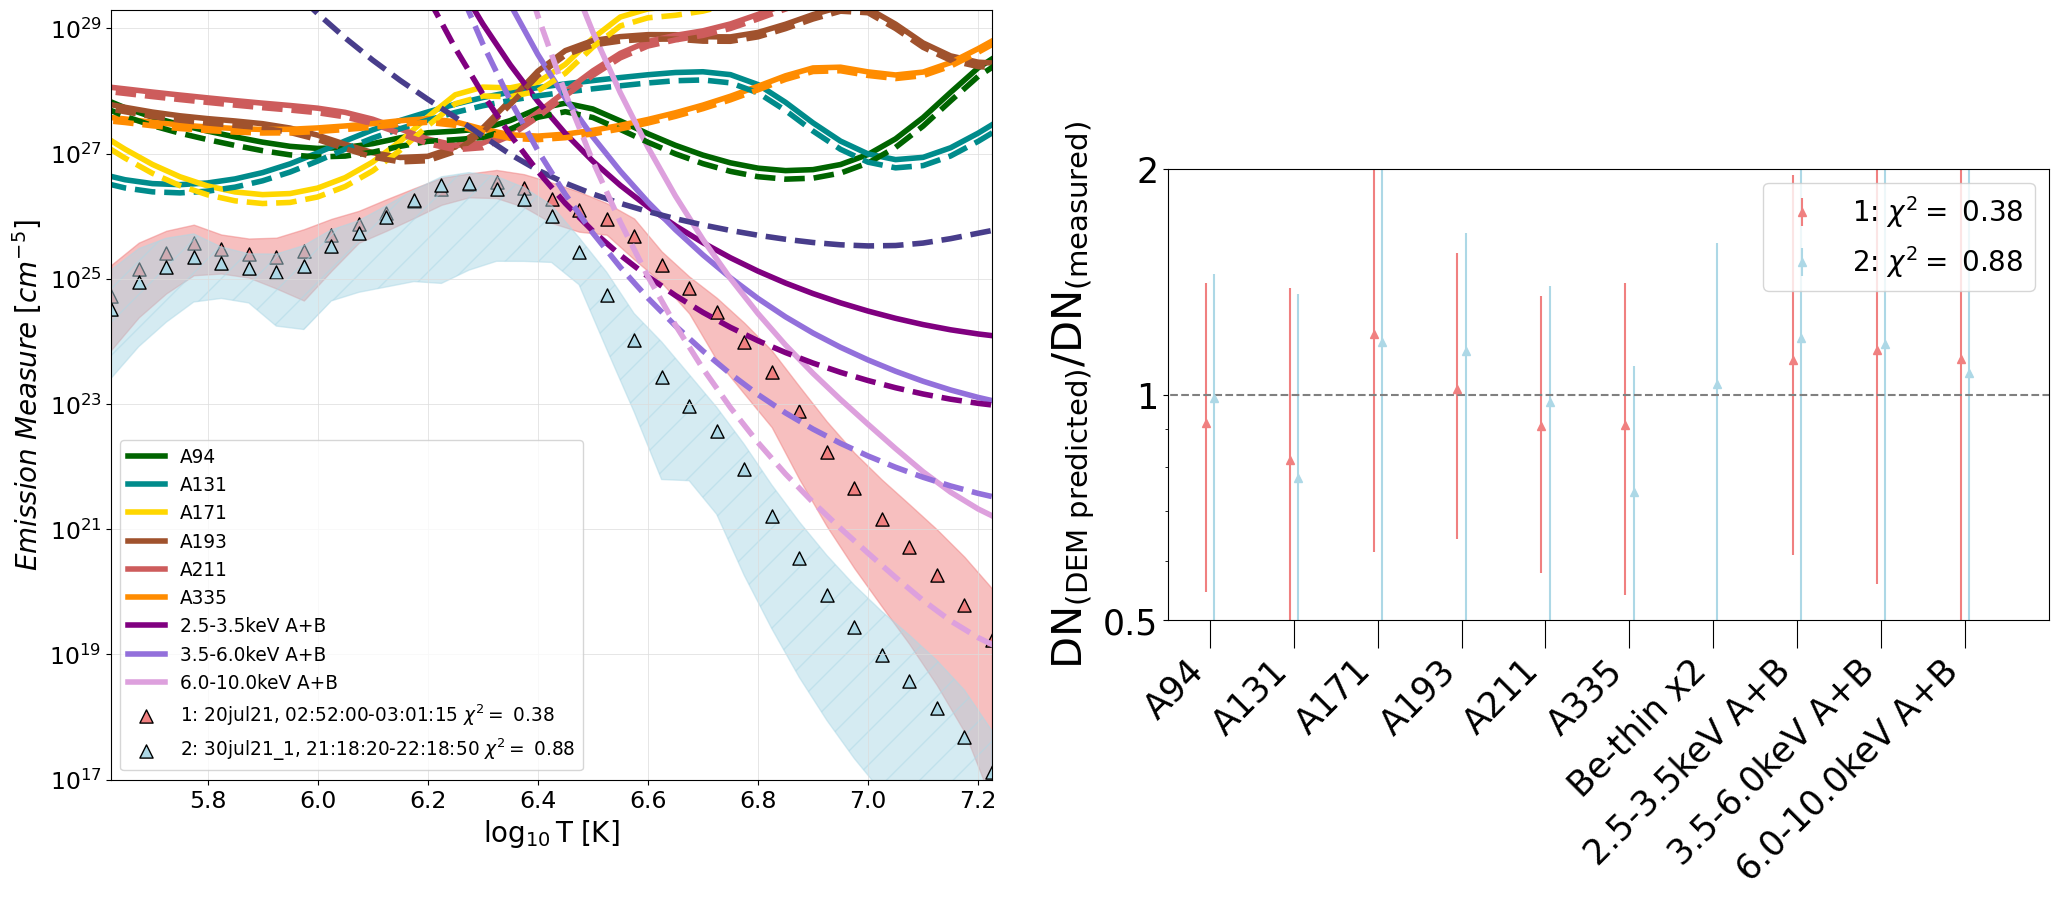

In [27]:
#Set to 0 for the initially southernmost, later easternmost region
#Set to 1 for the initially northernmost, later westernmost region
whichpair=0
file1 = all_targets['20-jul-21']['res_file_dict(s)'][whichpair]['quiet files all-inst'][0]
file2 = all_targets['30-jul-21_1']['res_file_dict(s)'][whichpair]['quiet files all-inst'][0]
print(file1)
print(file2)


fig = plt.figure(constrained_layout=True, figsize=(25,10))
gs = fig.add_gridspec(5, 2)
ax1 = fig.add_subplot(gs[0:5, 0])
ax2 = fig.add_subplot(gs[1:4, 1])


data1, timestring1, time1 = viz.load_DEM(file1)
data2, timestring2, time2 = viz.load_DEM(file2)
namest=file1.split('/')[6][12:]
namest2=file2.split('/')[6][12:]


#data1['fill_color'] = 'green'
#data2['fill_color'] = 'orange'
importlib.reload(viz)


viz.compare_DEMs(data1, data2, timestring1, timestring2, title1=namest+', '+mod_timestring(timestring1), 
                 title2=namest2+', '+mod_timestring(timestring2), 
                 plotMK=False, plot=True, working_dir=working_dir, input_ax=ax1, input_ax2=ax2)

ax1.tick_params(axis='both', labelsize=17)
#ax1.set_title('Comparison - Two Quiescent Times on '+namest, fontsize=labelfontsize)
ax1.set_title('', fontsize=labelfontsize)

#ax2.set_title('Residuals', fontsize=labelfontsize)
ax2.set_title('', fontsize=labelfontsize)
ax1.set_ylim([1e17, 2e29])
ax1.legend(ncols=1, fontsize=labelfontsize/1.5)


Clean up that extremely huge list (remove duplicates and order correctly in time). 

We now have a slightly less extremely huge list. 

In [ ]:
# list1=[]
# for cc in checked_times[0:600]:
#     if cc[0].iso.split()[0] == '2014-11-01':
#         list1.append(cc)

# print(len(list1))

In [ ]:
inconsistent_regions=[]
for ir in incons_regions:
    if not ir in inconsistent_regions:
        inconsistent_regions.append(ir)
        
inconsistent_regions

110 10 19
0
0
0
0
18-47-45 22-25-10


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

2016-04-22 18:47:45.908 2016-04-22 22:25:00.000
goesstep:  0:00:02.047000
8.204746393403185e-08 W / m2
[1751 1753 1754 1755]
03-21-15 05-41-25
Using 1s GOES flux ("flx1s")


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

goesstep:  0:00:01.000007
9.669040643700556e-08 W / m2
[4681]
11-12-35 19-24-40
Using 1s GOES flux ("flx1s")


...

2020-06-06 20:44:05.272 2020-06-08 21:49:04.803
goesstep:  0:00:01.000004
6.553871969572356e-07 W / m2
[90171]
14-53-45 22-15-50
Using 1s GOES flux ("flx1s")


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

goesstep:  0:00:01.000003
2.7641654014587403e-07 W / m2
[21615]
02-52-00 10-13-15
Using 1s GOES flux ("flx1s")


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

goesstep:  0:00:01.000002
3.447873609729868e-07 W / m2
[9103]
9 110 18 9


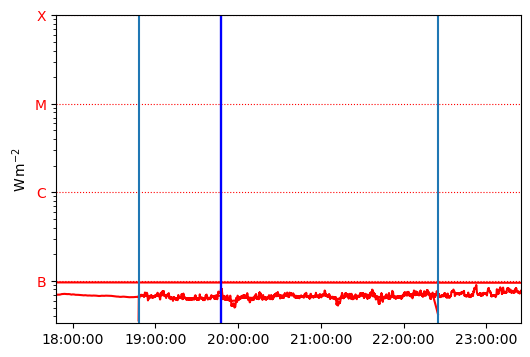

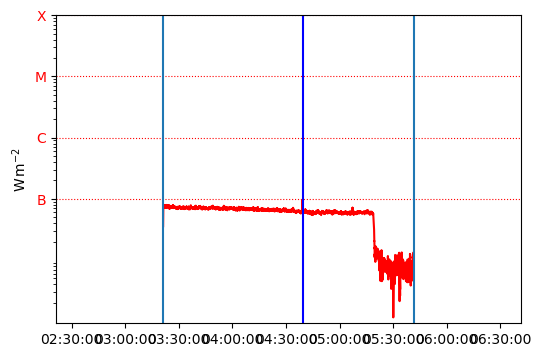

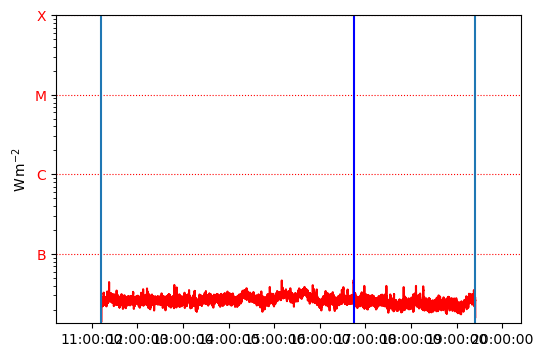

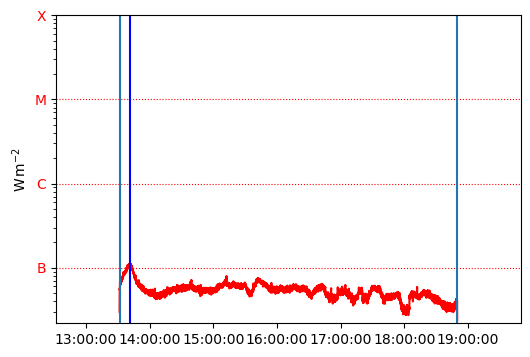

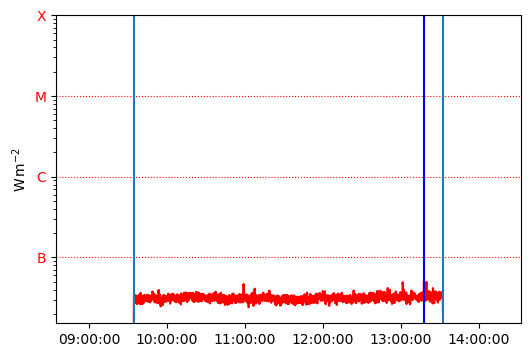

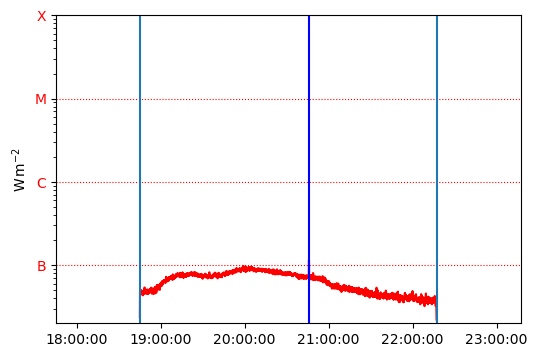

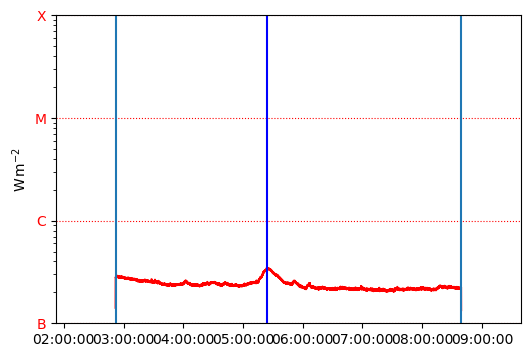

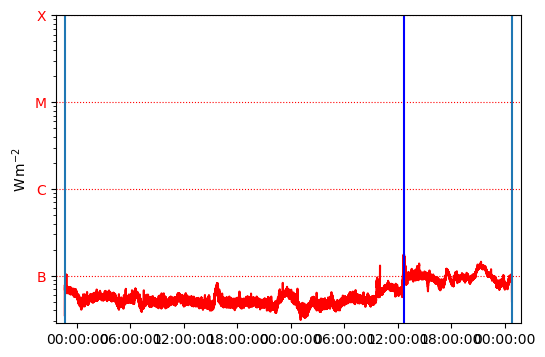

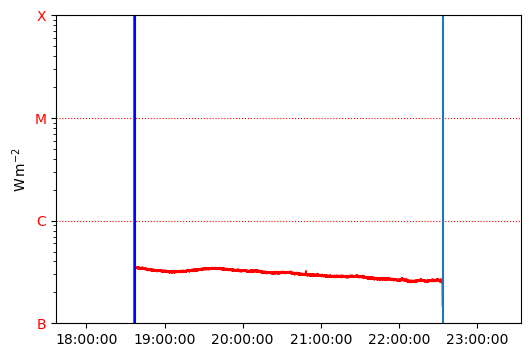

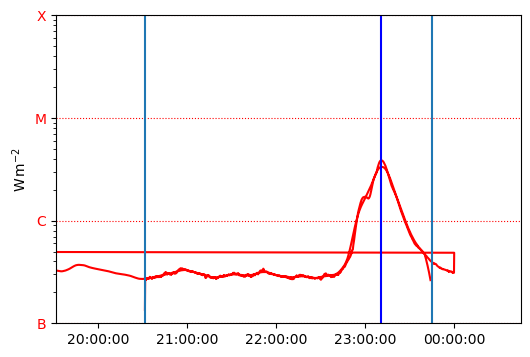

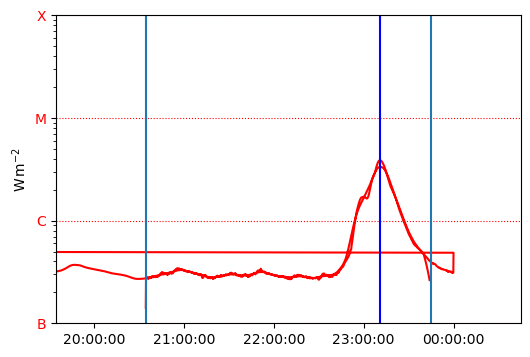

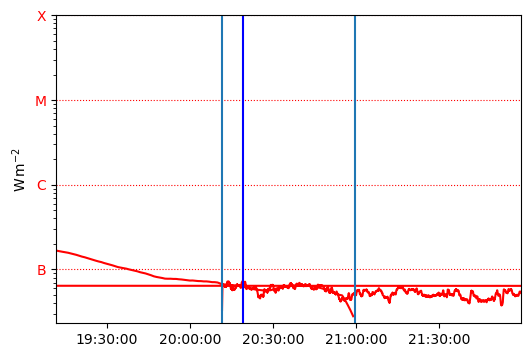

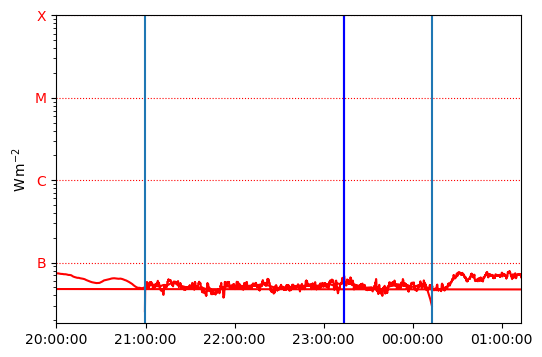

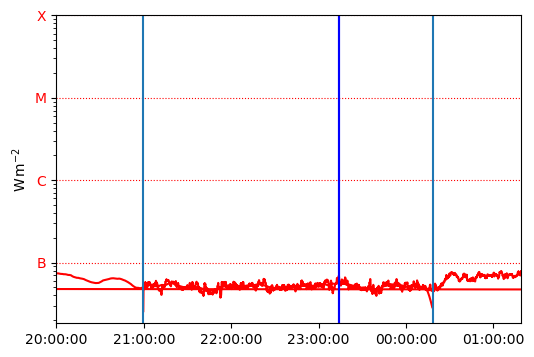

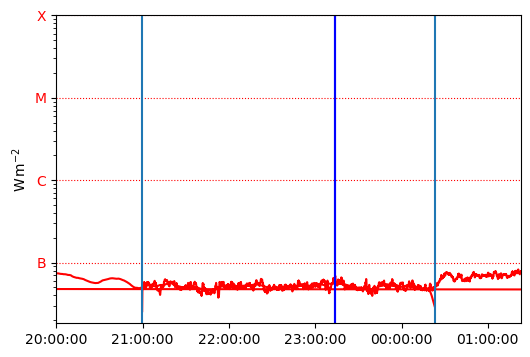

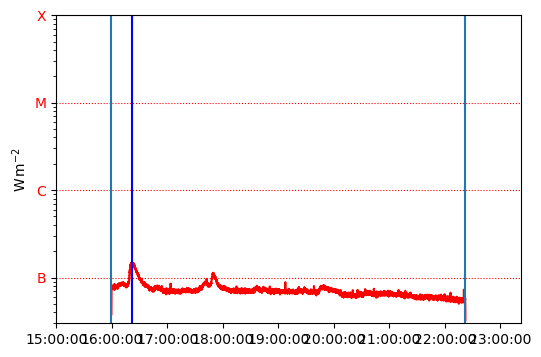

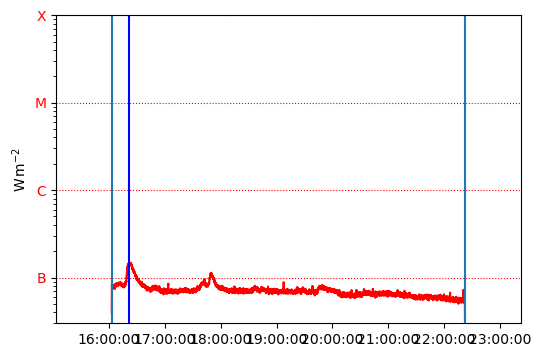

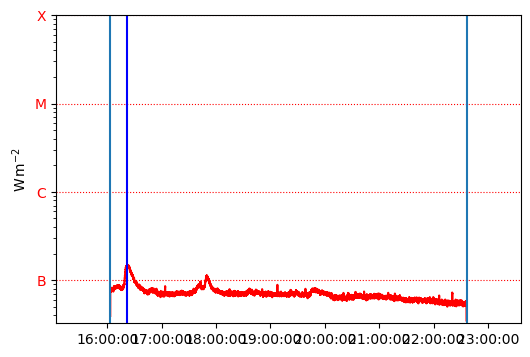

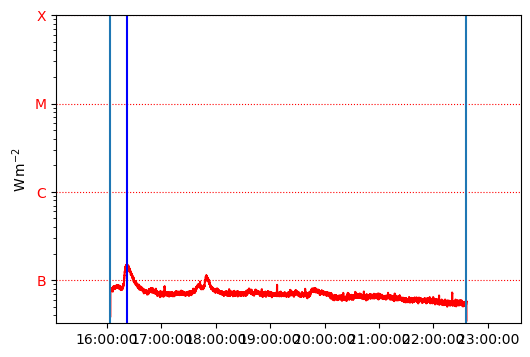

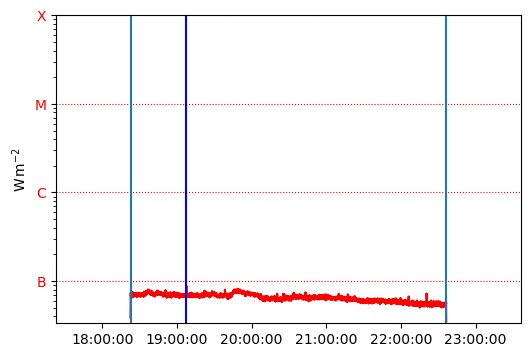

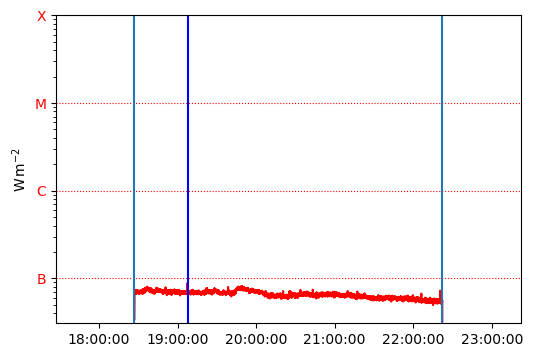

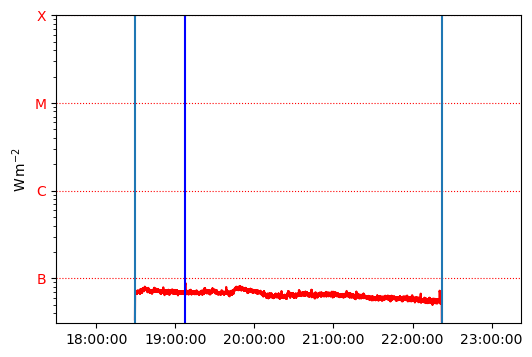

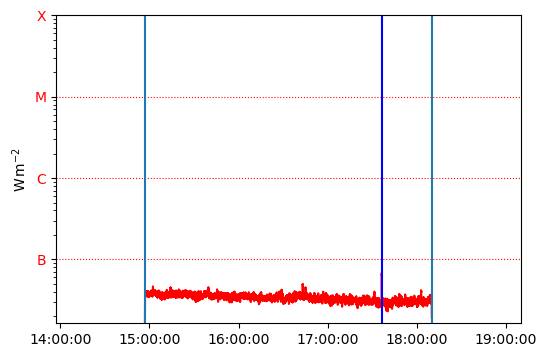

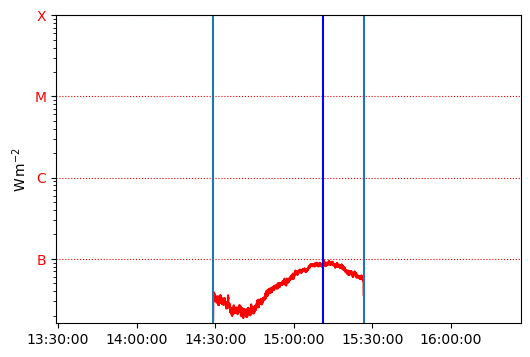

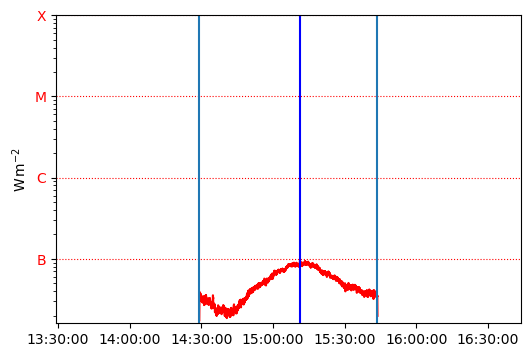

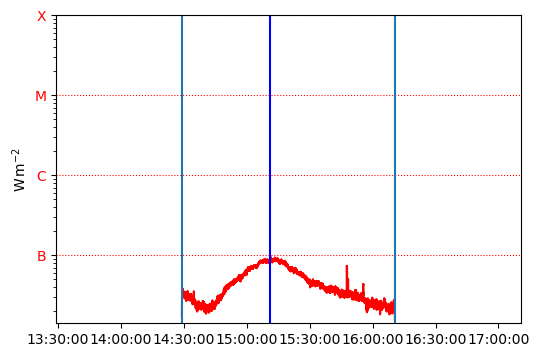

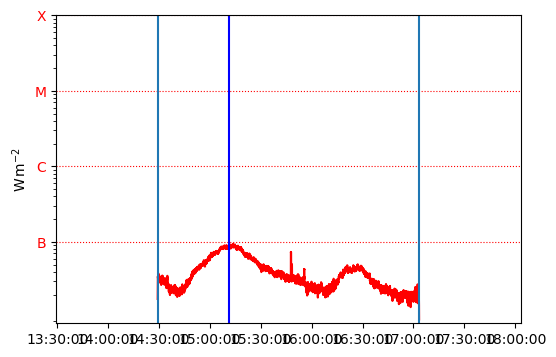

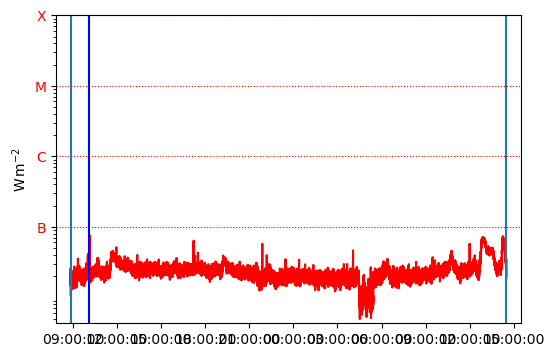

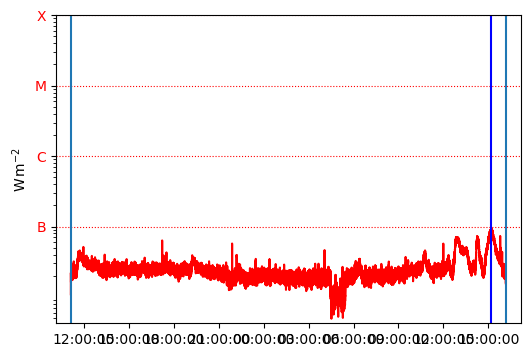

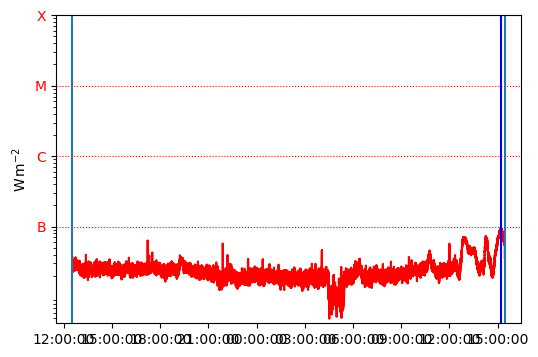

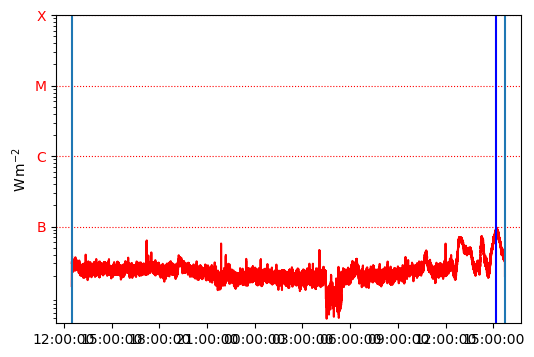

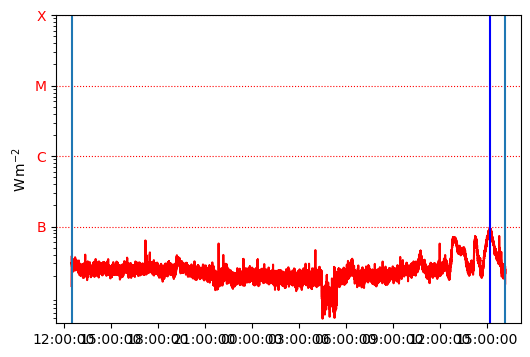

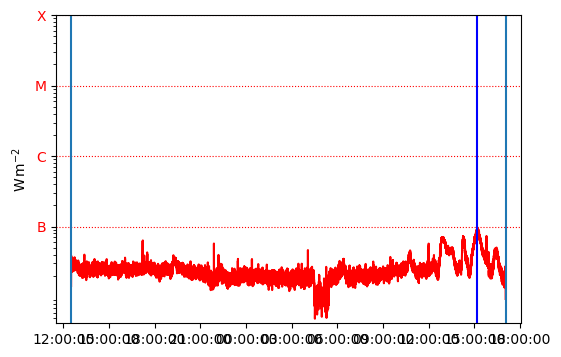

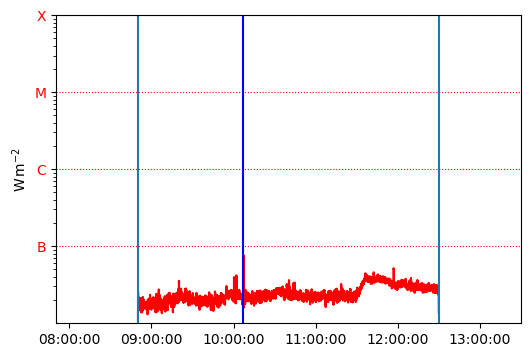

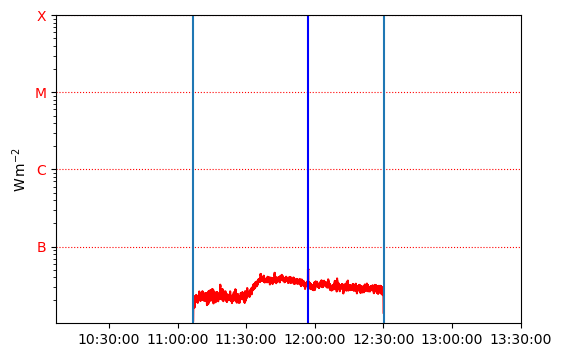

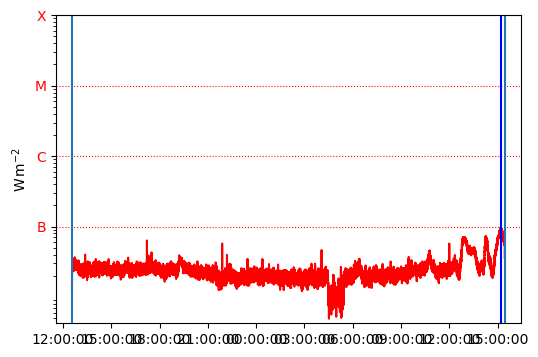

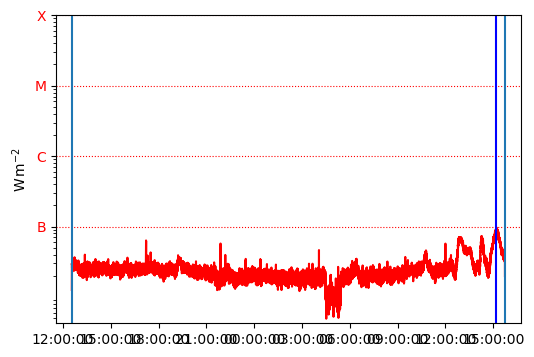

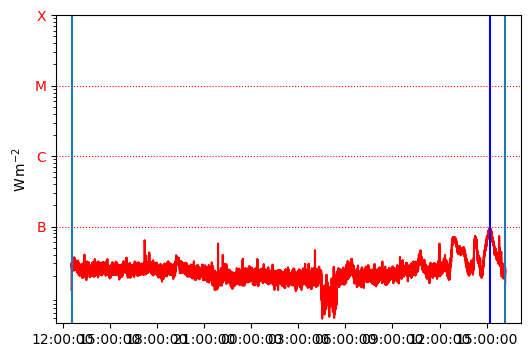

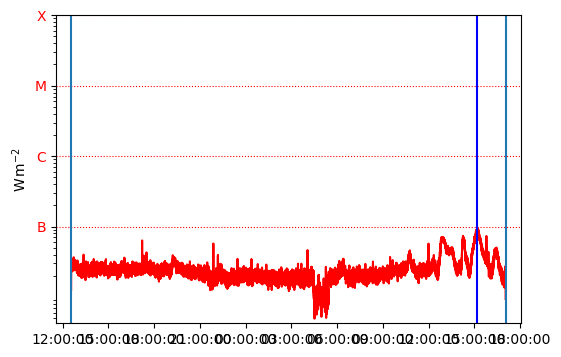

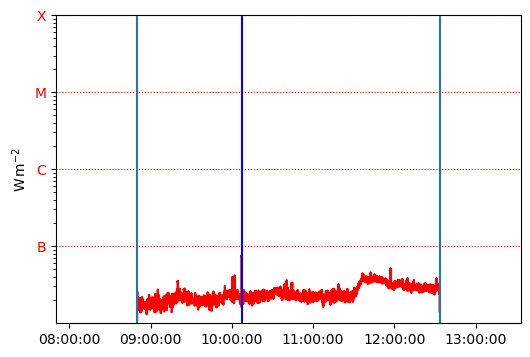

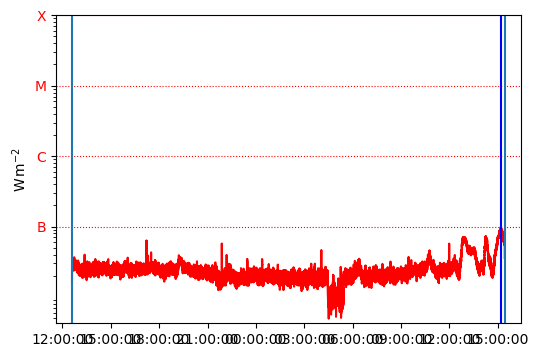

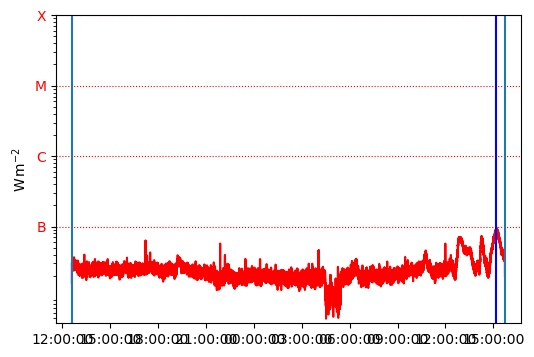

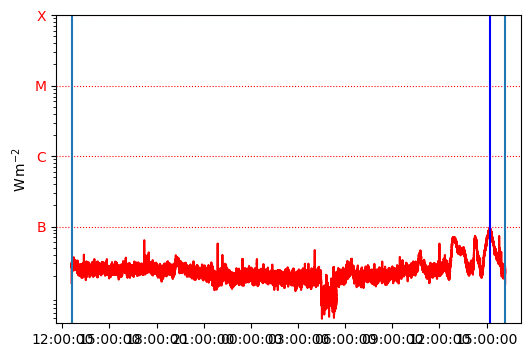

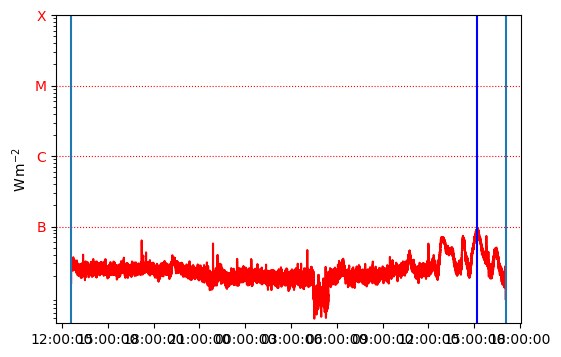

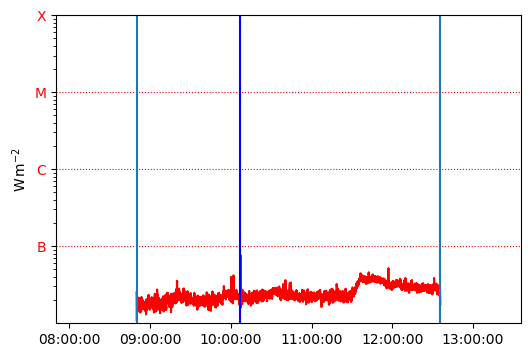

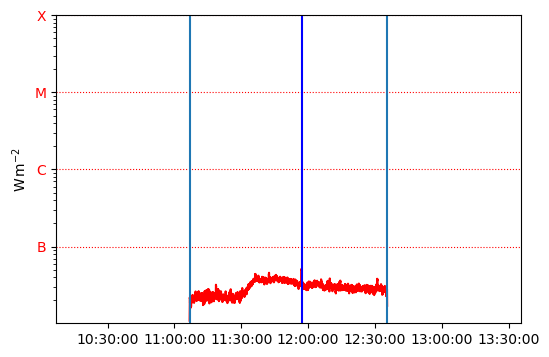

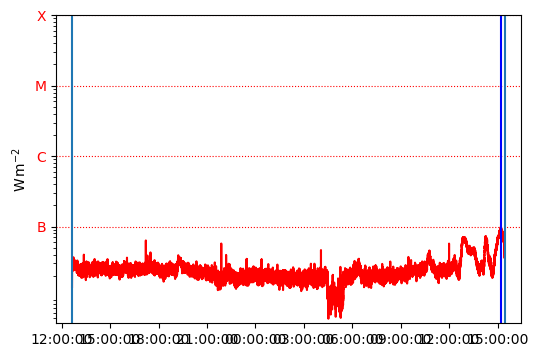

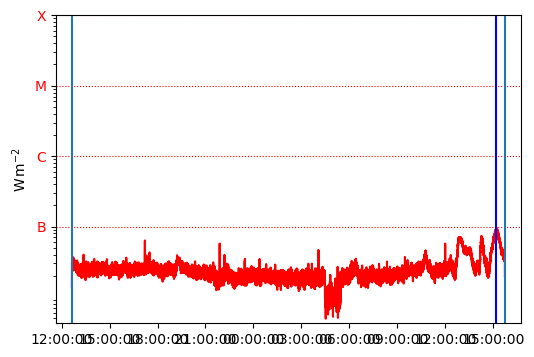

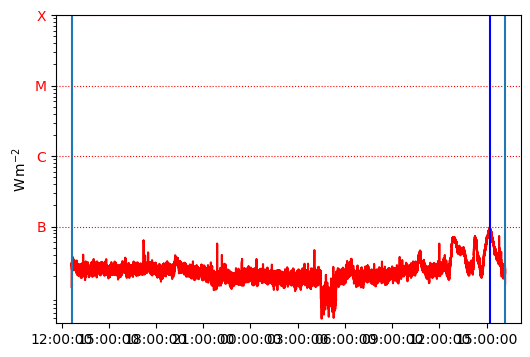

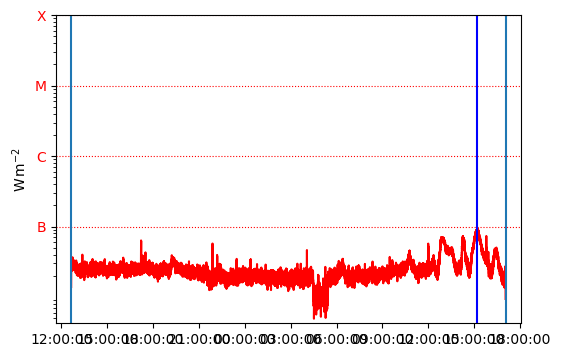

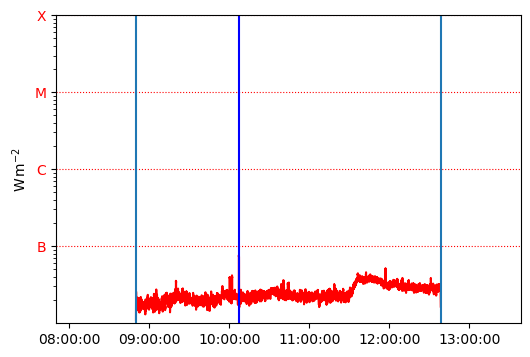

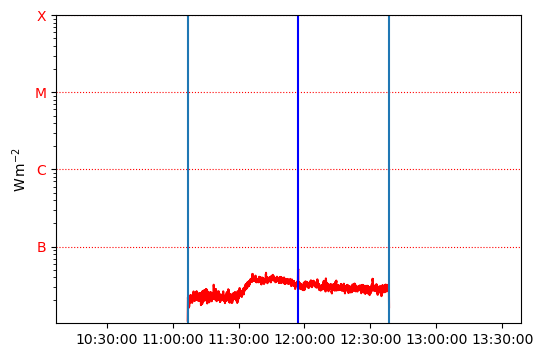

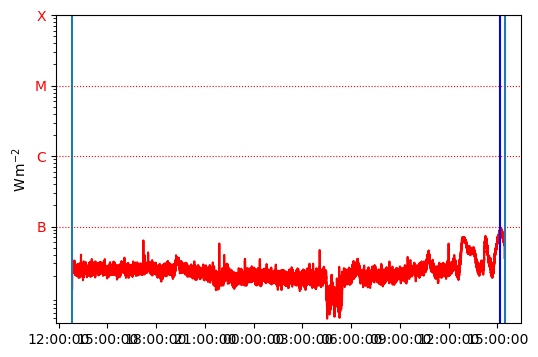

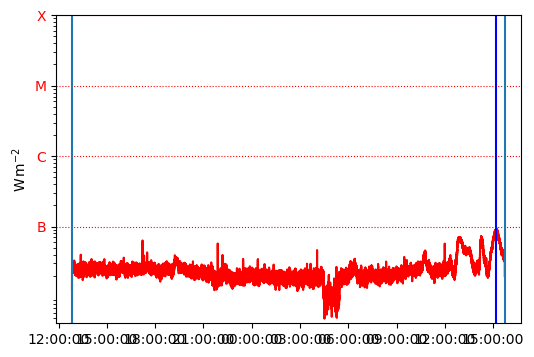

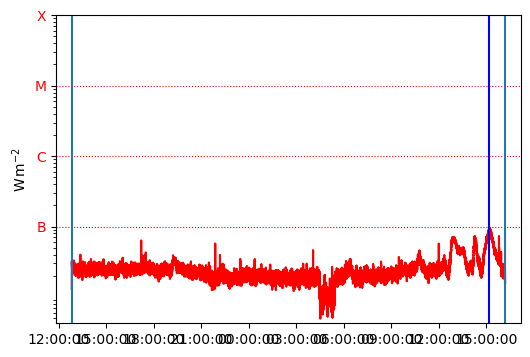

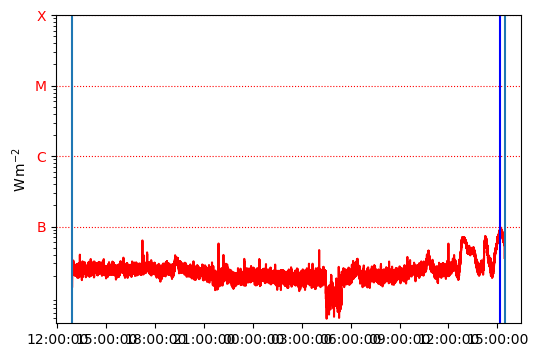

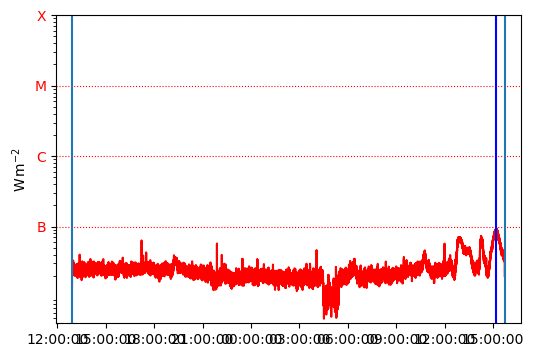

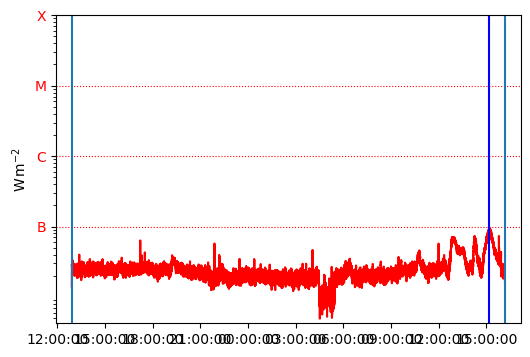

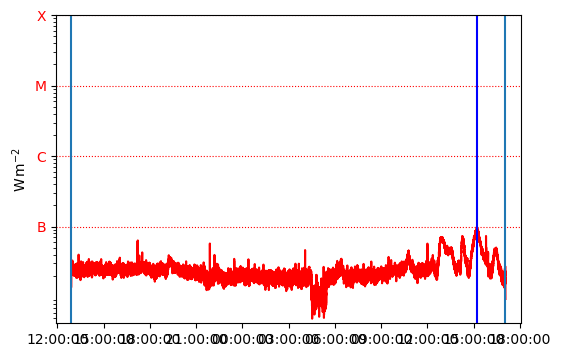

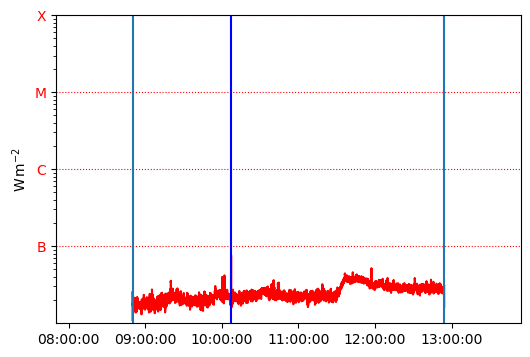

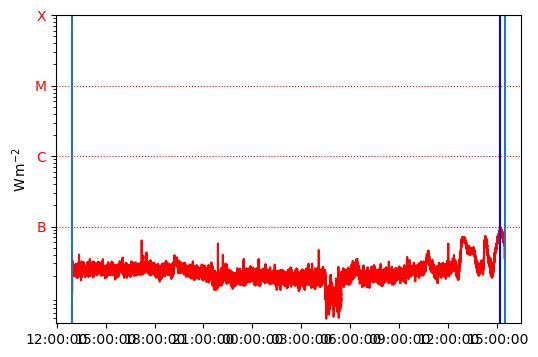

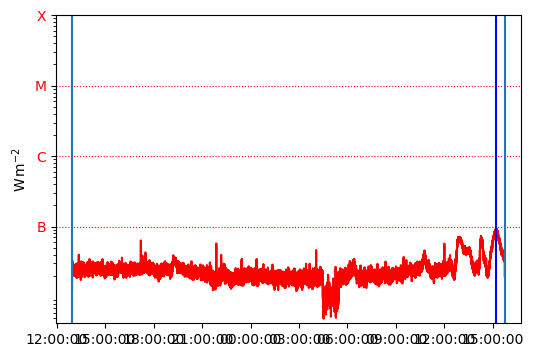

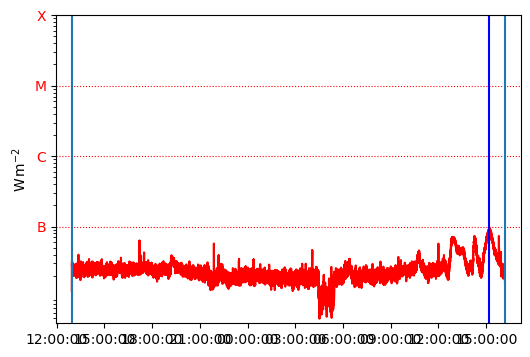

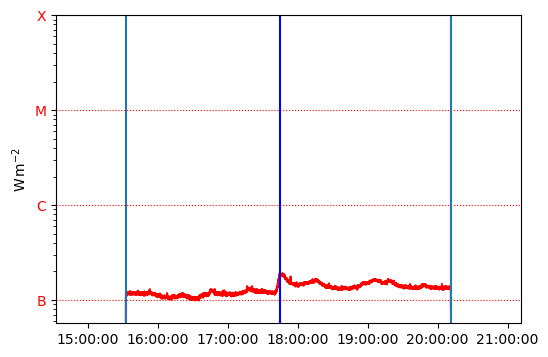

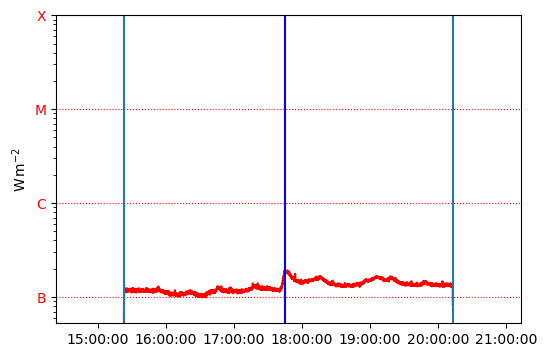

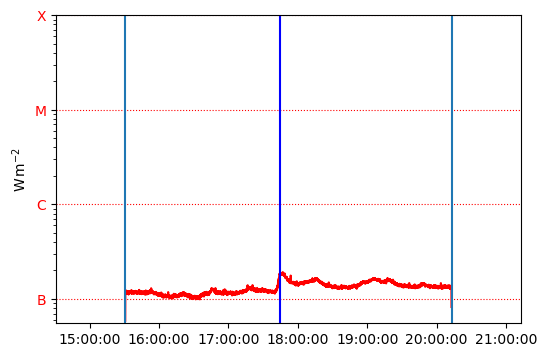

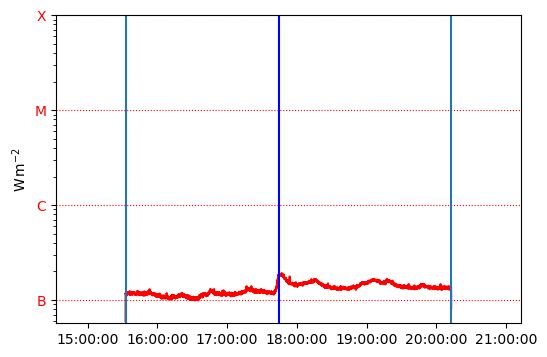

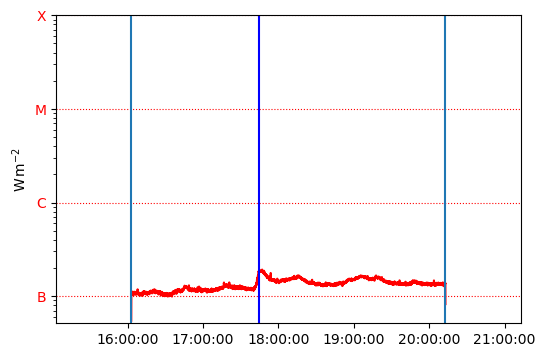

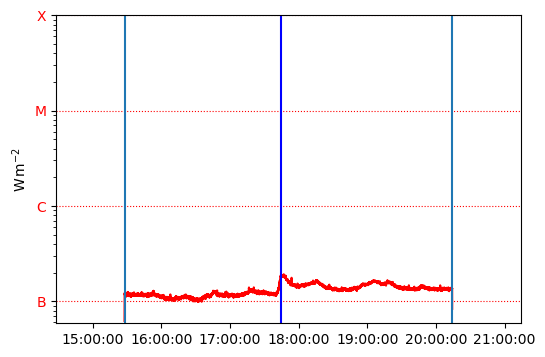

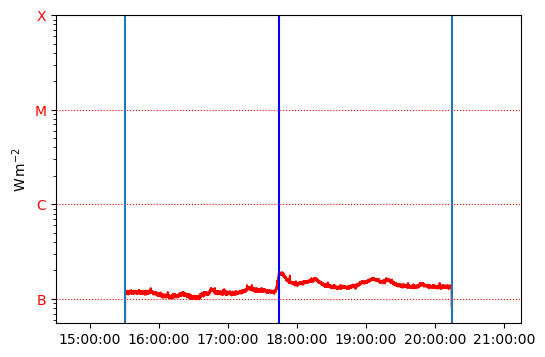

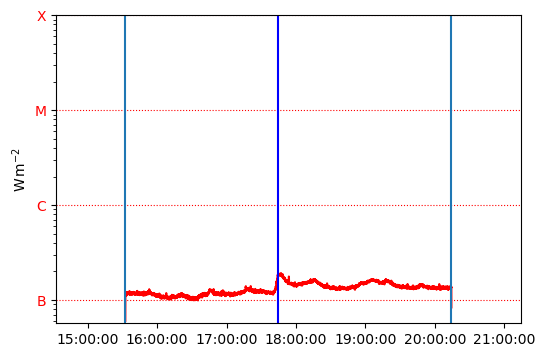

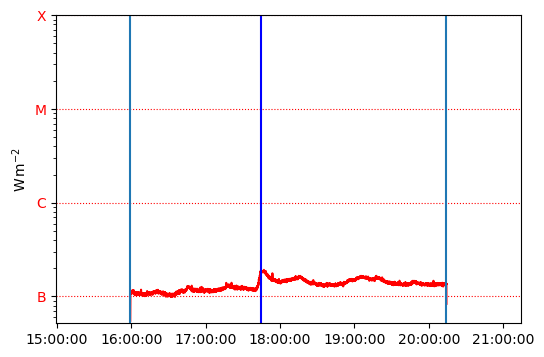

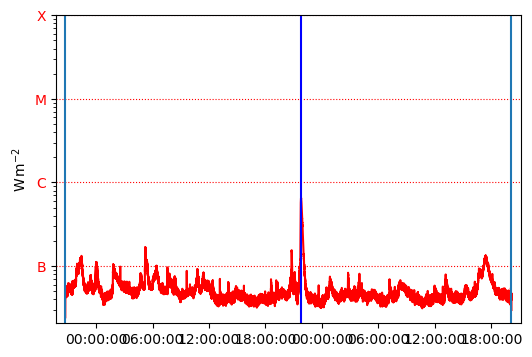

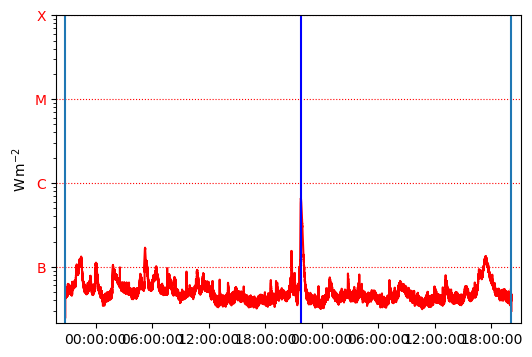

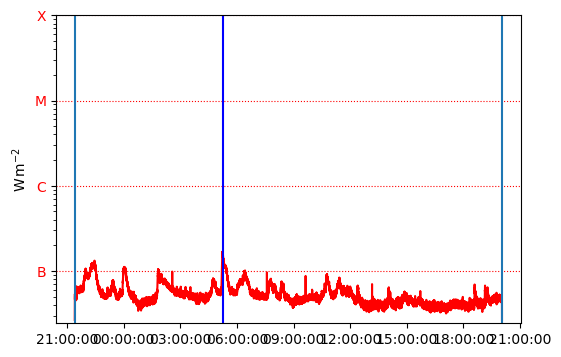

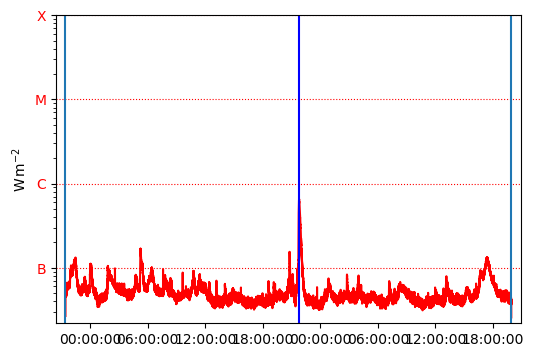

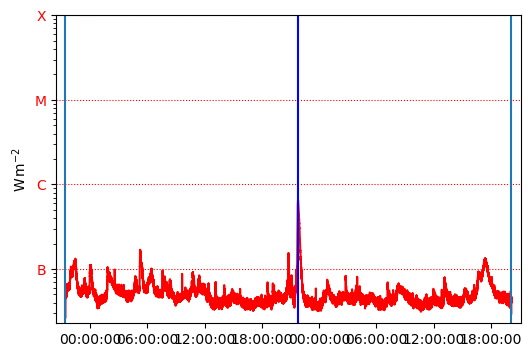

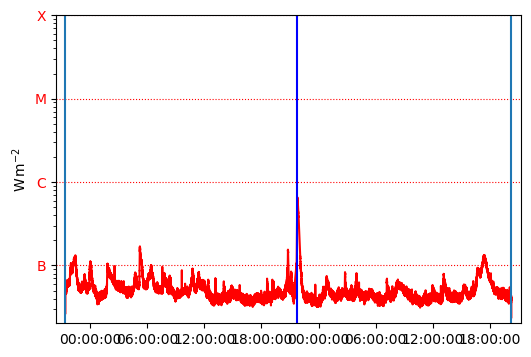

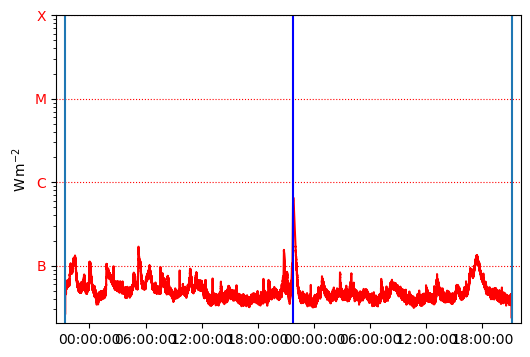

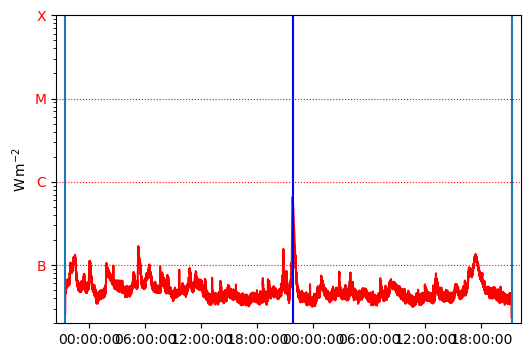

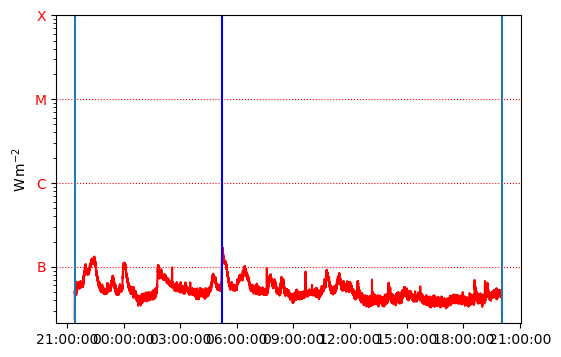

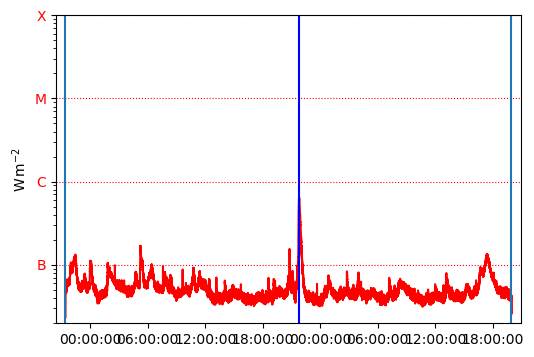

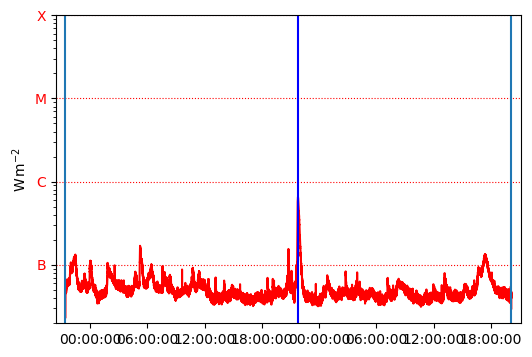

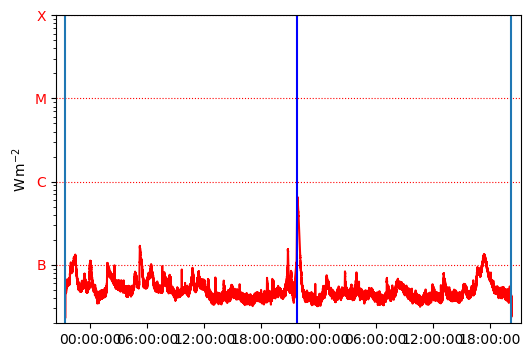

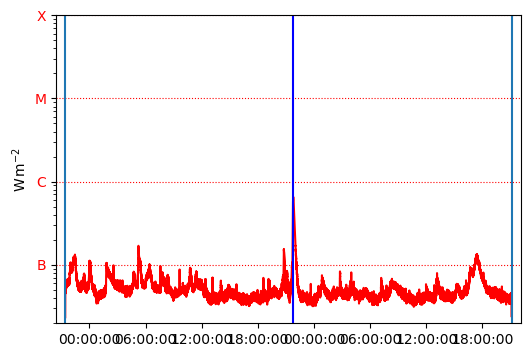

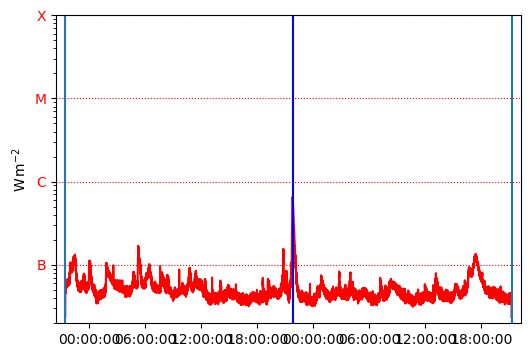

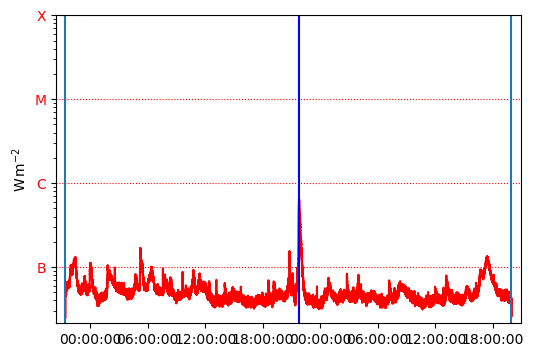

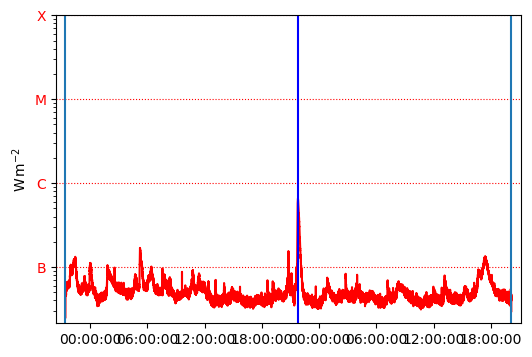

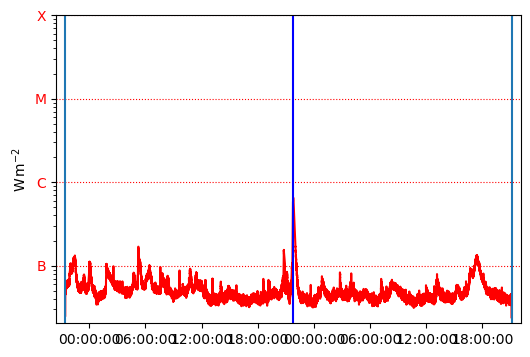

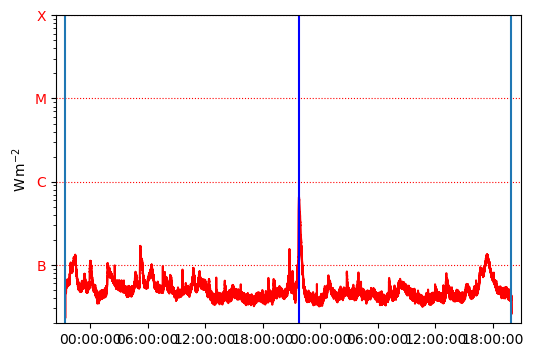

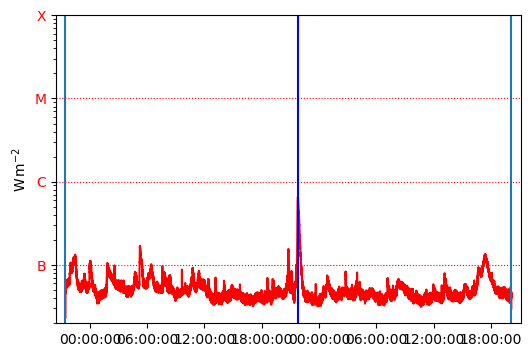

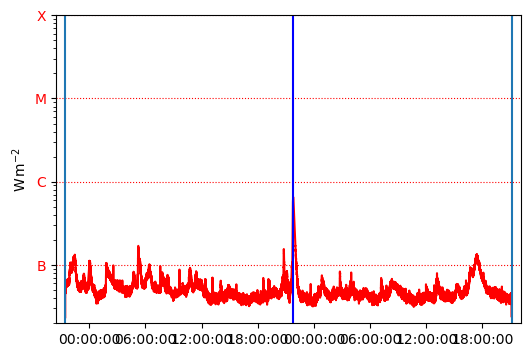

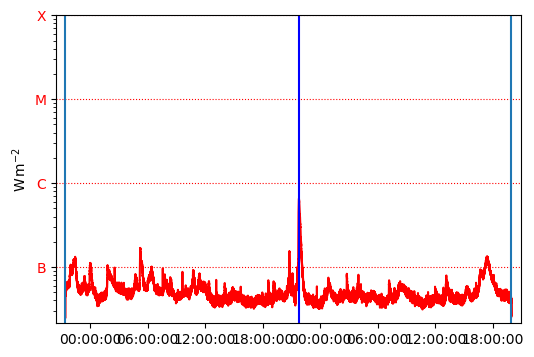

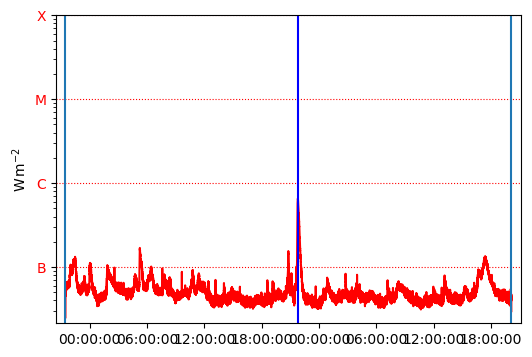

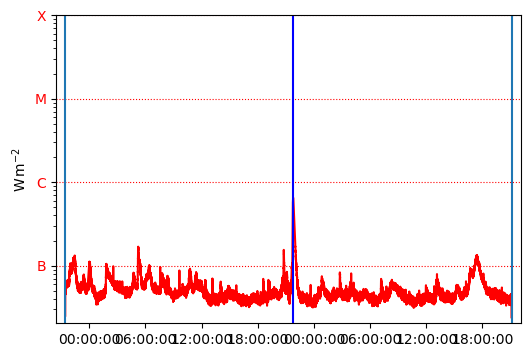

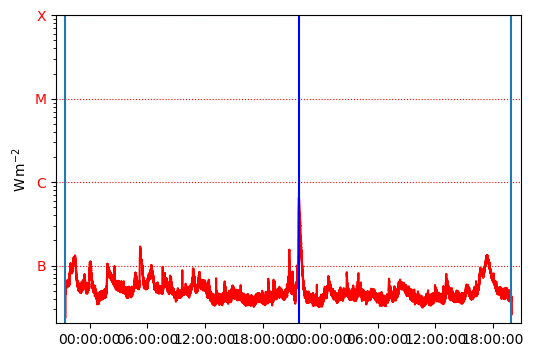

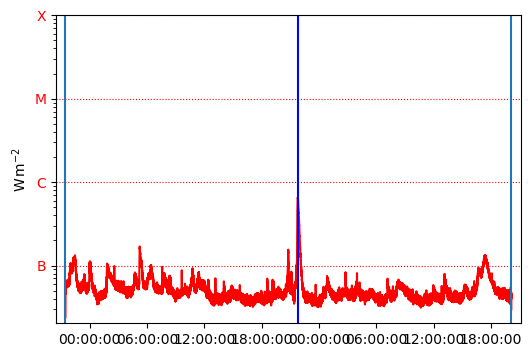

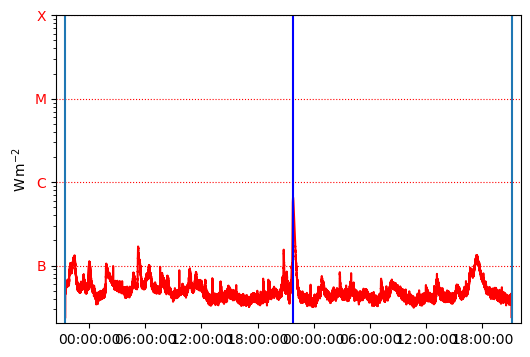

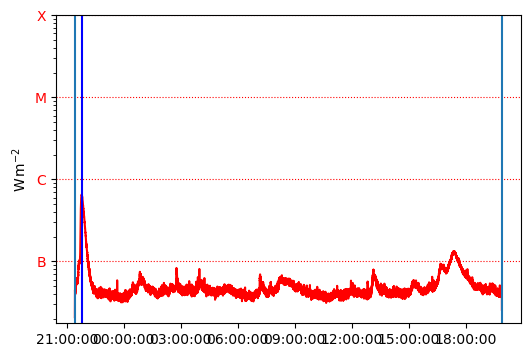

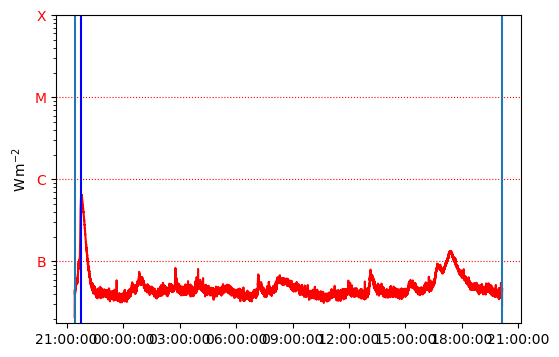

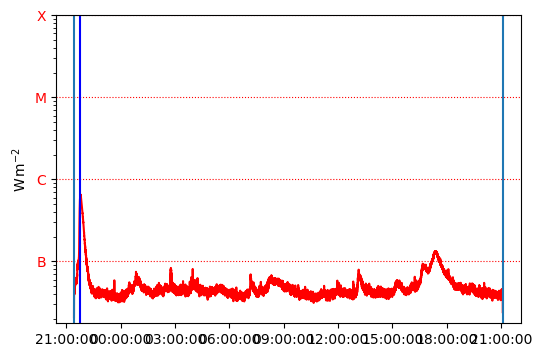

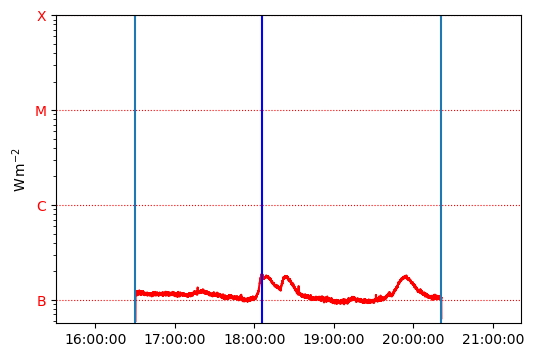

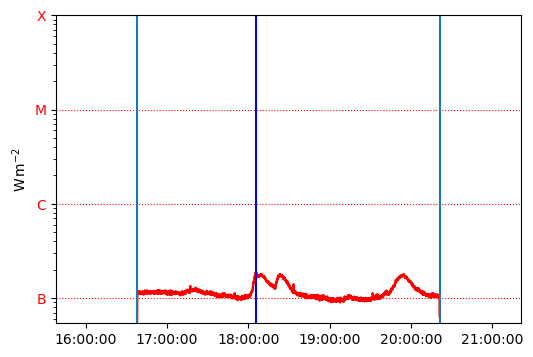

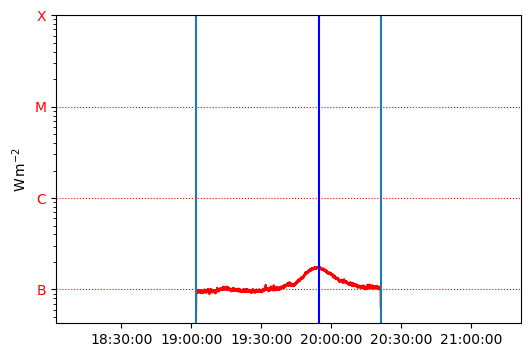

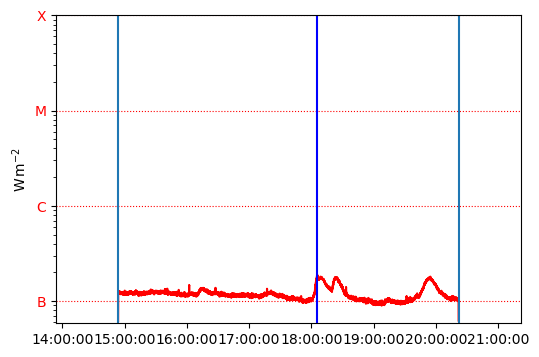

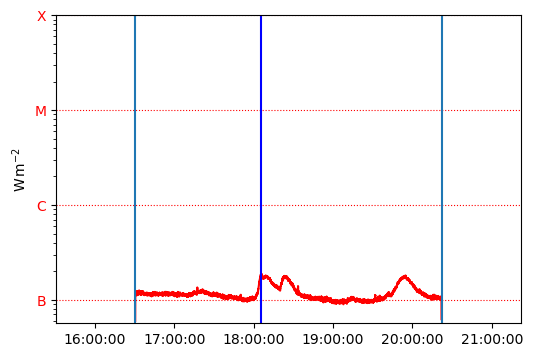

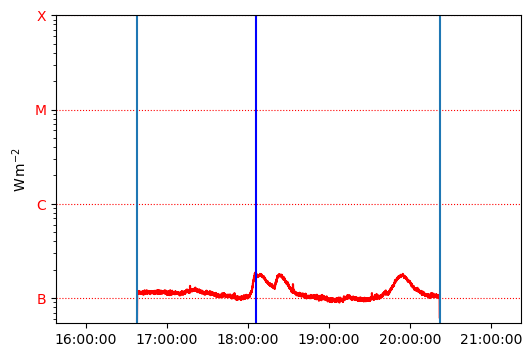

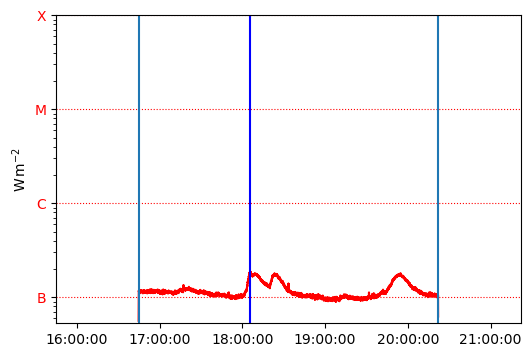

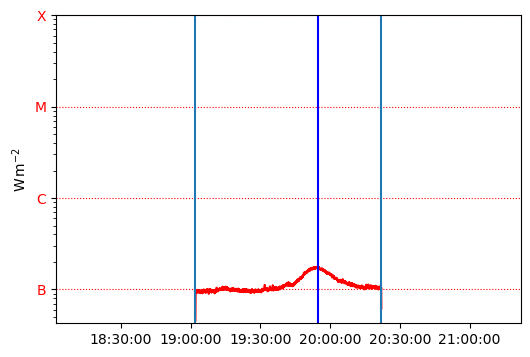

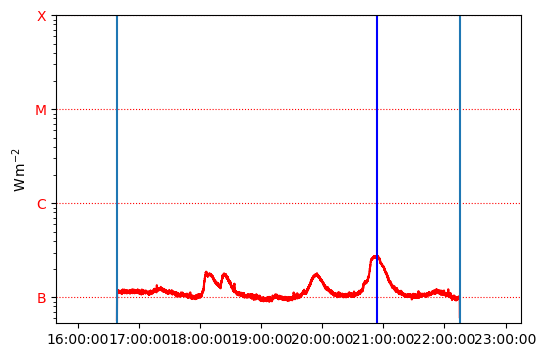

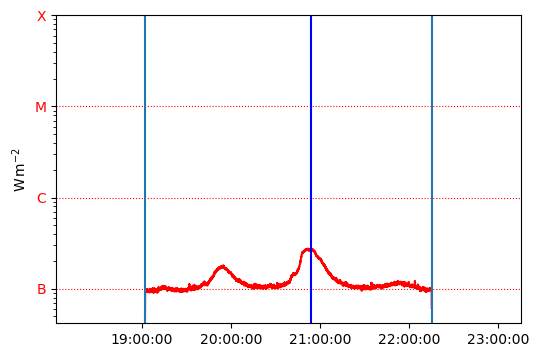

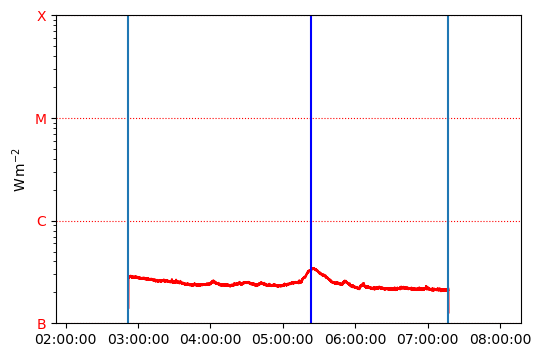

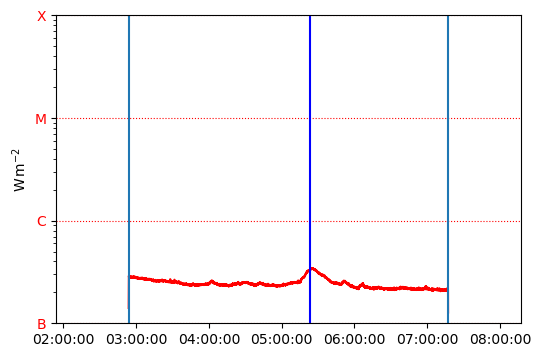

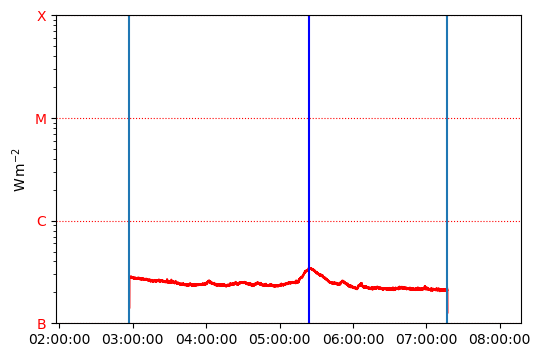

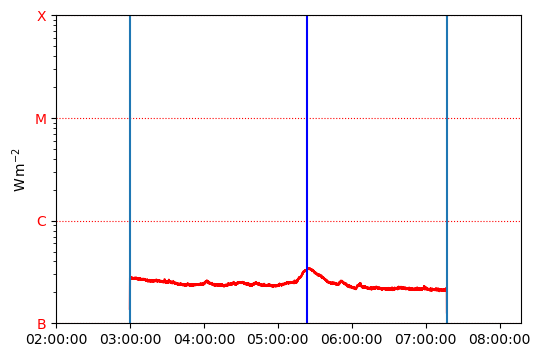

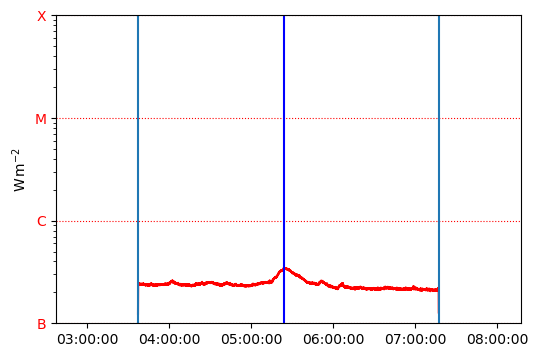

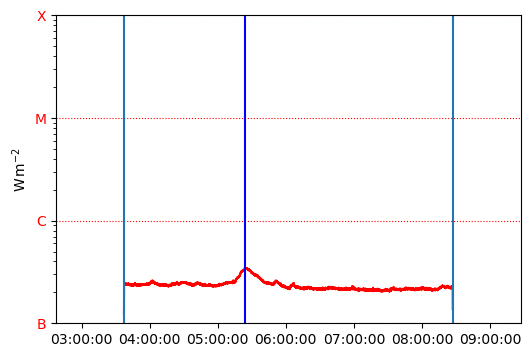

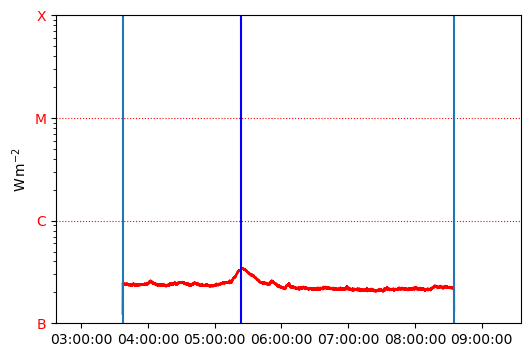

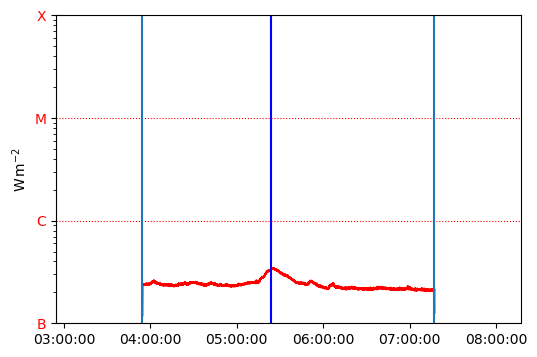

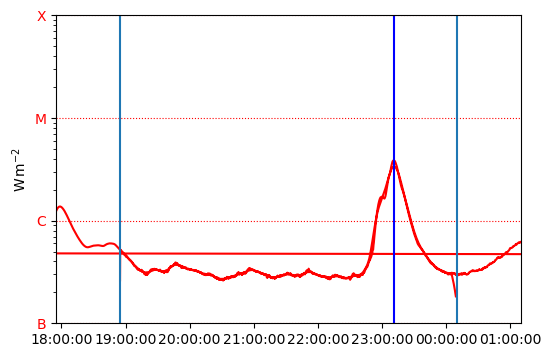

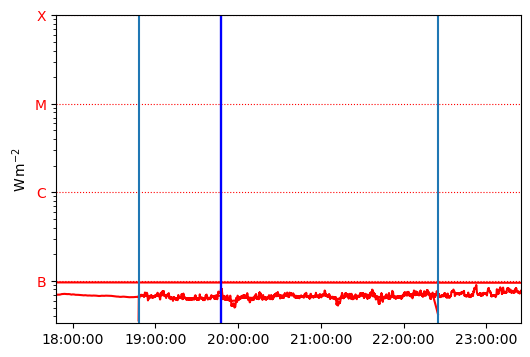

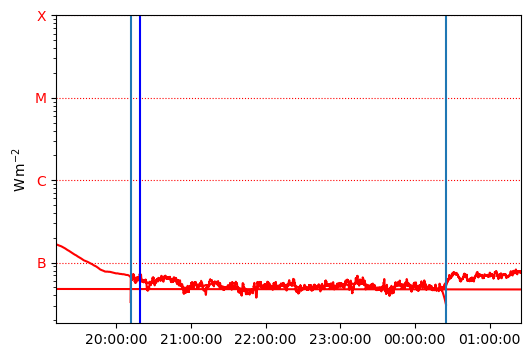

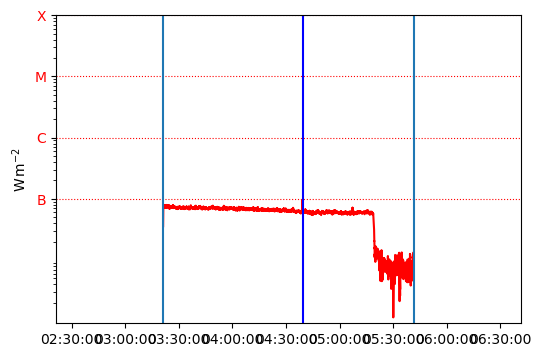

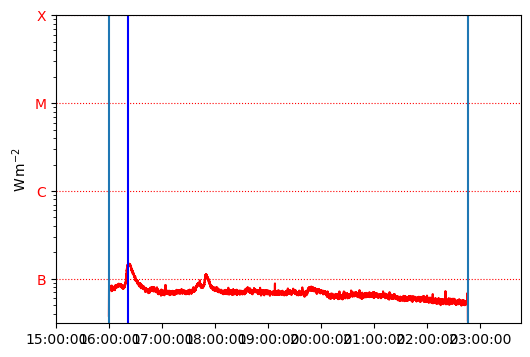

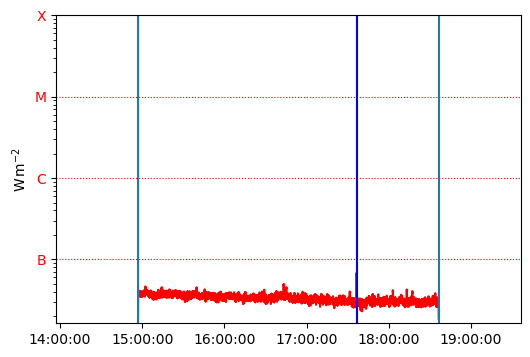

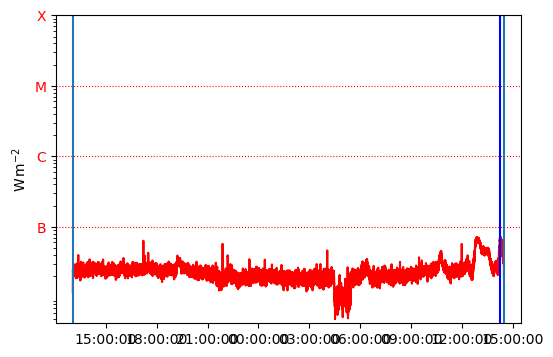

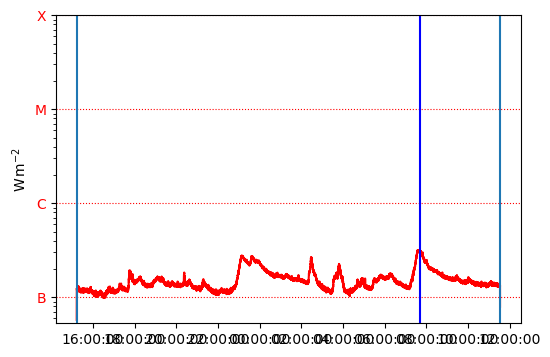

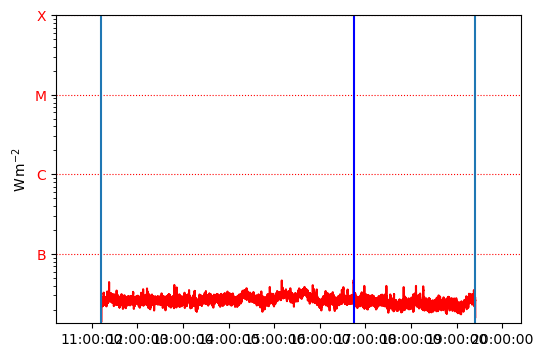

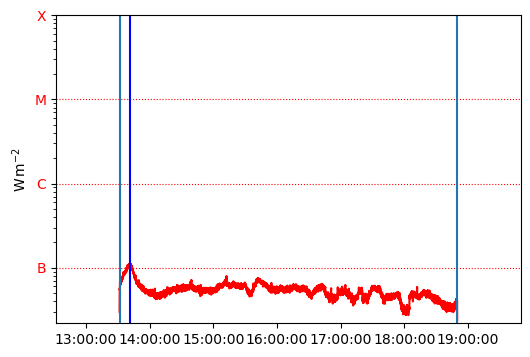

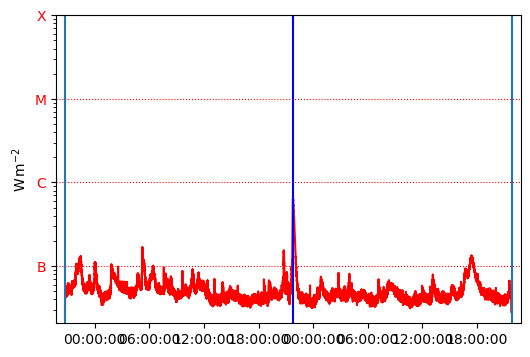

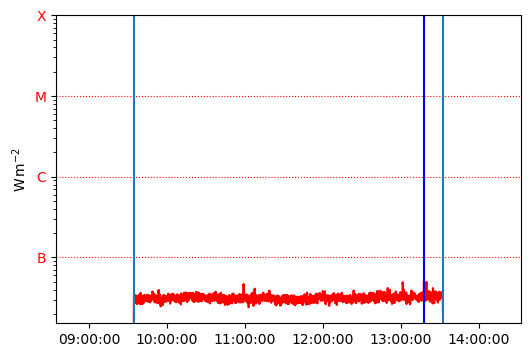

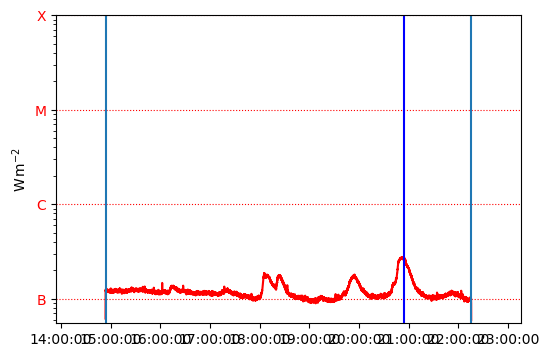

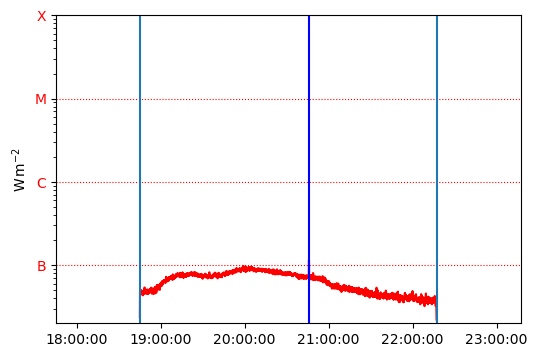

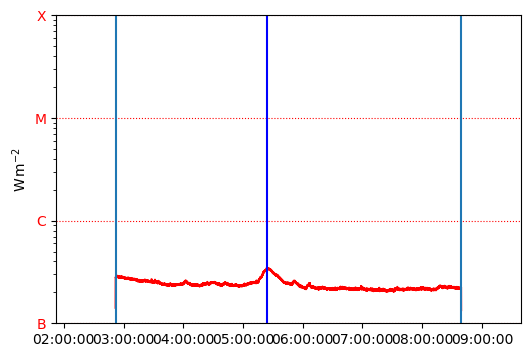

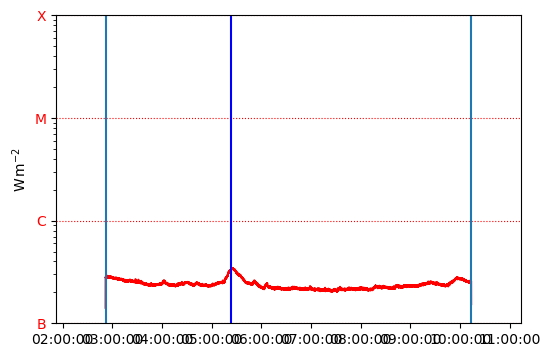

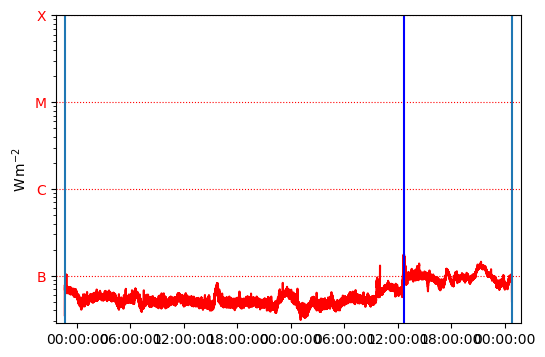

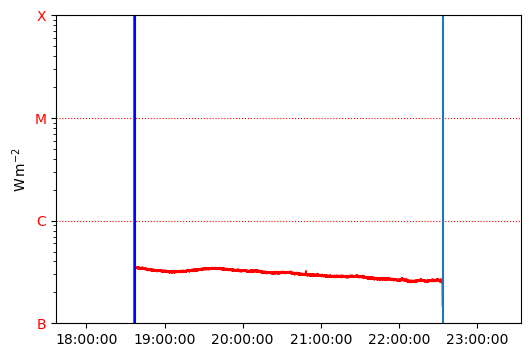

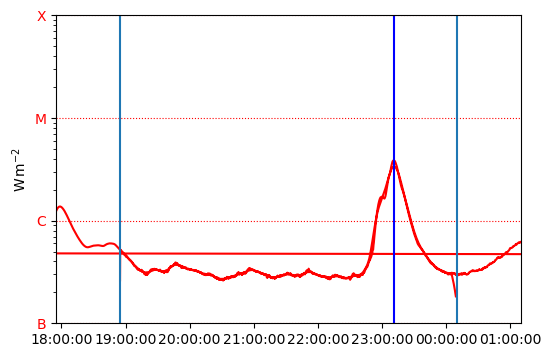

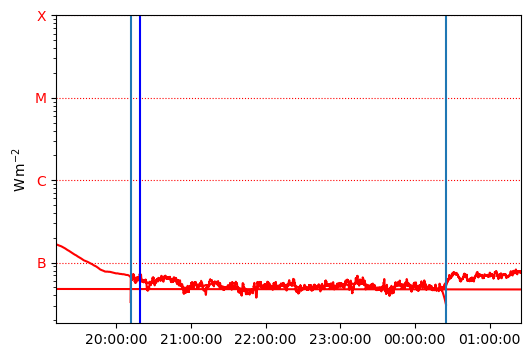

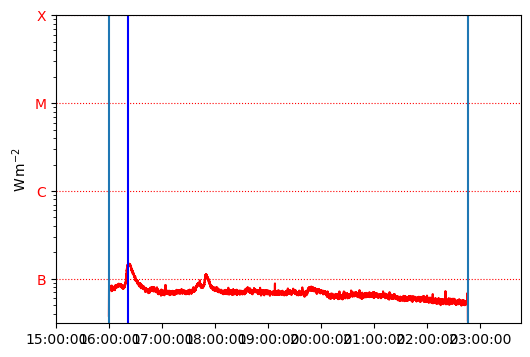

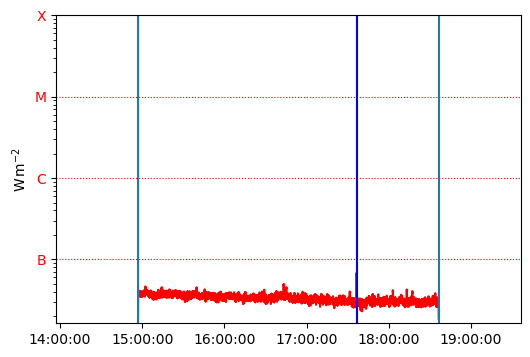

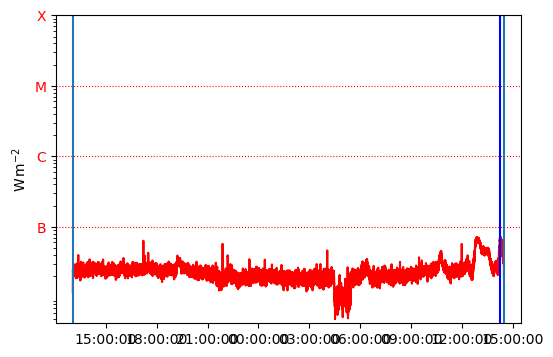

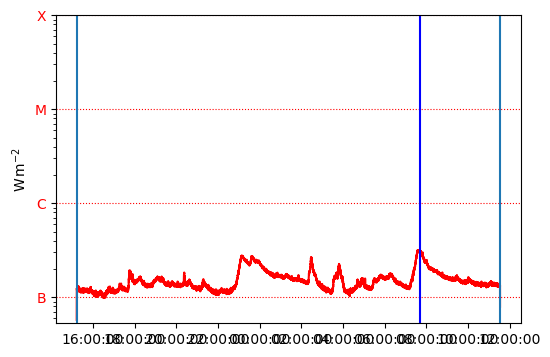

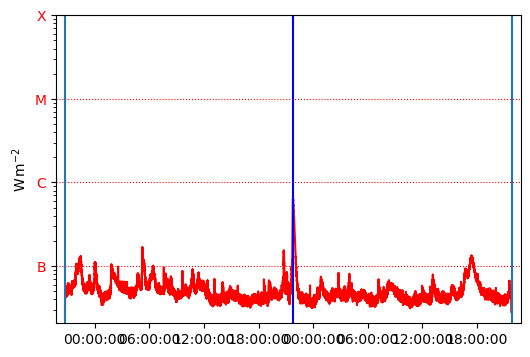

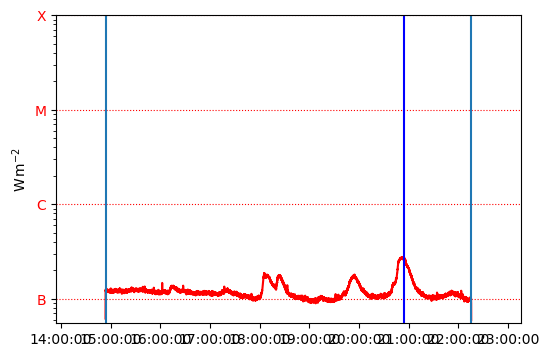

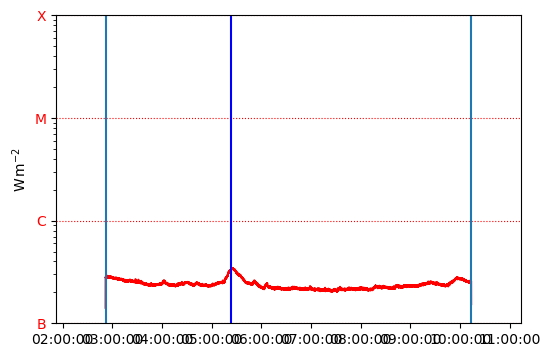

In [28]:
print(len(incons_times), len(cons_times), len(all_times))

[c.sort() for c in cons_times]
[c.sort() for c in incons_times]
[c.sort() for c in all_times]
[c.sort() for c in incons_full_times]

checked_incons_demcomp = make_clean_incons(incons_times)
checked_cons_demcomp = make_clean_incons(cons_times)
checked_all_demcomp = make_clean_incons(all_times)
checked_incons_full_times_demcomp = make_clean_incons(incons_full_times)

goesmax_fl_demcomp = get_intermediate_goesmaxes(checked_cons_demcomp)
goesmax_demcomp = get_intermediate_goesmaxes(checked_incons_demcomp)
goesmax_all_demcomp = get_intermediate_goesmaxes(checked_all_demcomp)
goesmax_incons_all_demcomp = get_intermediate_goesmaxes(checked_incons_full_times_demcomp)

print(len(goesmax_fl_demcomp), len(goesmax_demcomp), len(goesmax_all_demcomp), len(goesmax_incons_all_demcomp))

#Maximum GOES flux observed during each inconsistent interval
goesmaxv_demcomp = [g.value[0] if type(g.value) == np.ndarray else g.value for g in goesmax_demcomp]
#Avoids double counting, say, two adjacent intervals inconsistent with the same other interval, where the intermediate peak is the same
#goesmaxvs_demcomp = list(set(goesmaxv_demcomp))
goesmaxvs_demcomp = goesmaxv_demcomp


#Maximum goes flux observed during each full consistent observation
goesmaxvs_fl_demcomp = [g.value[0] if type(g.value) == np.ndarray else g.value for g in goesmax_fl_demcomp]
#goesmaxvs_fl_demcomp = list(set(goesmaxv_fl_demcomp))

#Maximum GOES flux observed during each full observation
goesmaxvs_all_demcomp = [g.value[0] if type(g.value) == np.ndarray else g.value for g in goesmax_all_demcomp]
#goesmaxvs_all_demcomp = list(set(goesmaxv_all_demcomp))

#Maximum GOES flux observed during each full INCONSISTENT observation
goesmaxvs_incons_all_demcomp = [g.value[0] if type(g.value) == np.ndarray else g.value for g in goesmax_incons_all_demcomp]
#goesmaxvs_incons_all_demcomp = list(set(goesmax_incons_all_demcomp))

All region mean duration (hours):  11.879254385964911 med:  5.300277777777777
Internally-consistent region mean duration (hours):  8.925583333333332 med:  3.959722222222223
Non internally-consistent region mean duration (hours):  15.16111111111111 med:  7.354166666666665

All region GOES 1-8 $\AA$max mean/median:  B 4.0 B 1.3
Internally-consistent region GOES max mean/median:  B 1.5 B 1.1
Non internally-consistent region GOES max mean/median:  B 6.5 B 2.8
Time pairs GOES max mean/median:  B 3.4 B 1.8


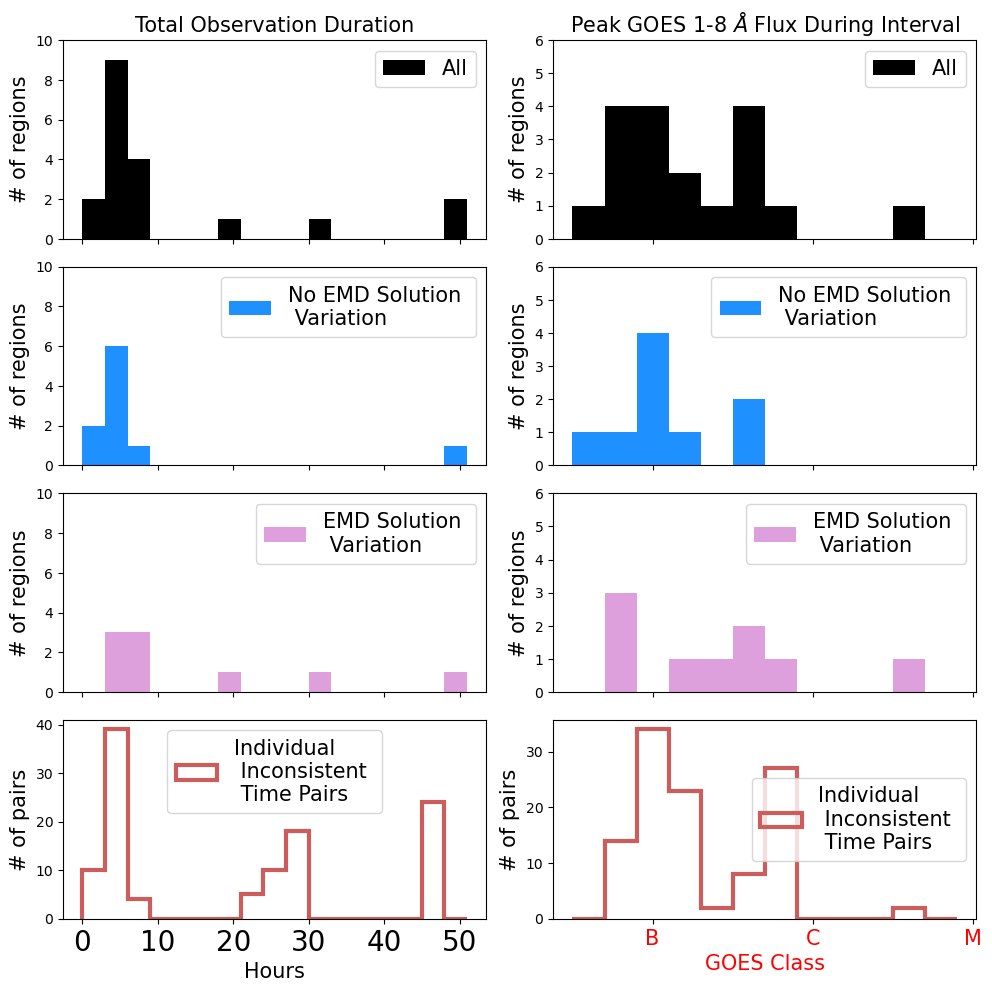

In [39]:
figfontsize=15

ads = [ad.to(u.h).value for ad in all_durs_demcomp]
#ads.extend([cd.to(u.h).value for cd in contig_durs])
cds = [ad.to(u.h).value for ad in cons_durs_demcomp]
#cds.extend([cd.to(u.h).value for cd in contig_durs])
ncds = [ad.to(u.h).value for ad in noncons_durs_demcomp]
#print(ads)
print('All region mean duration (hours): ', np.mean(ads), 'med: ', np.median(ads))
#print(cds)
print('Internally-consistent region mean duration (hours): ',np.mean(cds), 'med: ', np.median(cds))
#print(ncds)
print('Non internally-consistent region mean duration (hours): ',np.mean(ncds), 'med: ', np.median(ncds))

fig, ax = plt.subplots(4, 2, figsize=(10,10), tight_layout = {'pad': 1},  sharex='col')


dbins = np.arange(0,52,3)

ax[0,0].set_title('Total Observation Duration', fontsize=15)
ax[0,0].hist(ads, bins=dbins, #label='All Non-Contiguous \n Regions', 
             label='All', color='black')
ax[0,0].set_ylim([0,10])
ax[0,0].set_ylabel('# of regions', fontsize=figfontsize)
ax[0,0].legend(fontsize=figfontsize)

ax[1,0].hist(cds, bins=dbins, label='No EMD Solution \n Variation', color='dodgerblue')
ax[1,0].set_ylim([0,10])
ax[1,0].set_ylabel('# of regions', fontsize=figfontsize)
ax[1,0].legend(fontsize=figfontsize)

incons_seps=[]
for pp in checked_incons_demcomp:
    durh = (pp[1]-pp[0]).to(u.hr)
    incons_seps.append(durh.value)
    # if durh > 15*u.hr:
    #     print(durh, pp[0])


ax[2,0].hist(ncds, bins=dbins, label='EMD Solution \n Variation', color='plum')
#ax[3,0].hist(incons_seps, bins=dbins, label='Individual \n Inconsistent \n Time Pairs',  
#             histtype='step', edgecolor='indianred', linewidth=lw)
ax[2,0].set_ylim([0,10])
ax[2,0].set_ylabel('# of regions', fontsize=figfontsize)
#ax[2,0].set_xlabel('Hours', fontsize=figfontsize)
ax[2,0].legend(fontsize=figfontsize)


ax[3,0].hist(incons_seps, bins=dbins, label='Individual \n Inconsistent \n Time Pairs',  
             histtype='step', edgecolor='indianred', linewidth=lw)
ax[3,0].set_ylabel('# of pairs', fontsize=figfontsize)
ax[3,0].set_xlabel('Hours', fontsize=figfontsize)
ax[3,0].legend(fontsize=figfontsize)
ax[3,0].xaxis.set_ticks(np.arange(0,60,10), labels=[str(n) for n in np.arange(0,60,10)], color='black', fontsize=labelfontsize)

labelfontsize=15
tbins=np.arange(-7.5,-5, 0.2)
lw=3

ax[0,1].set_title('Peak GOES'+" 1-8 $\AA$"+' Flux During Interval', fontsize=15)
ax[0,1].hist(np.log10(goesmaxvs_all_demcomp), bins=tbins, label='All', color='black')
#ax[0,1].xaxis.set_ticks([-7, -6, -5], labels=['B', 'C','M'], color='red', fontsize=labelfontsize)
#ax[0,1].set_xlabel(r'log [$W m^{-2}$]')
ax[0,1].set_ylim([0, 6])
ax[0,1].set_ylabel('# of regions', fontsize=figfontsize)
ax[0,1].legend(fontsize=figfontsize)

ax[1,1].hist(np.log10(goesmaxvs_fl_demcomp), bins=tbins, label='No EMD Solution \n Variation', color='dodgerblue')
#ax[1,1].xaxis.set_ticks([-7, -6, -5], labels=['B', 'C','M'], color='red', fontsize=labelfontsize)
#ax[1,1].set_xlabel(r'log [$W m^{-2}$]')
ax[1,1].set_ylim([0, 6])
ax[1,1].set_ylabel('# of regions', fontsize=figfontsize)
ax[1,1].legend(fontsize=figfontsize)

ax[2,1].hist(np.log10(goesmaxvs_incons_all_demcomp), bins=tbins, label='EMD Solution \n Variation',  color='plum')
#ax[3,1].hist(np.log10(goesmaxvs_demcomp), bins=tbins, label='Individual \n Inconsistent \n Time Pairs',  
#             histtype='step', edgecolor='indianred', linewidth=lw)
ax[2,1].xaxis.set_ticks([-7, -6, -5], labels=['B', 'C', 'M'], color='red', fontsize=labelfontsize)
#ax[2,1].set_xlabel(r'log [$W m^{-2}$]', fontsize=figfontsize)
ax[2,1].set_ylim([0, 6])
ax[2,1].set_ylabel('# of regions', fontsize=figfontsize)
ax[2,1].legend(fontsize=figfontsize)

ax[3,1].hist(np.log10(goesmaxvs_demcomp), bins=tbins, label='Individual \n Inconsistent \n Time Pairs',  
             histtype='step', edgecolor='indianred', linewidth=lw)
ax[3,1].xaxis.set_ticks([-7, -6, -5], labels=['B', 'C', 'M'], color='red', fontsize=labelfontsize)
#ax[3,1].set_xlabel(r'$log_{10}$ [$W m^{-2}$]', fontsize=figfontsize)
ax[3,1].set_xlabel('GOES Class', fontsize=figfontsize, color='red')
ax[3,1].set_ylabel('# of pairs', fontsize=figfontsize)
ax[3,1].legend(fontsize=figfontsize)


print('')

print('All region GOES '+"1-8 $\AA$"+'max mean/median: ', 'B', round(np.mean(goesmaxvs_all_demcomp)/1e-7, 1), 
      'B', round(np.median(goesmaxvs_all_demcomp)/1e-7, 1))
print('Internally-consistent region GOES max mean/median: ', 'B', round(np.mean(goesmaxvs_fl_demcomp)/1e-7, 1),
      'B', round(np.median(goesmaxvs_fl_demcomp)/1e-7, 1))
print('Non internally-consistent region GOES max mean/median: ', 'B', round(np.mean(goesmaxvs_incons_all_demcomp)/1e-7, 1),
      'B', round(np.median(goesmaxvs_incons_all_demcomp)/1e-7, 1))
print('Time pairs GOES max mean/median: ', 'B', round(np.mean(goesmaxvs_demcomp)/1e-7, 1),
      'B', round(np.median(goesmaxvs_demcomp)/1e-7, 1))


plt.savefig('dem_based_consistency_vs_duration.png', dpi=300)

In [ ]:
print(np.mean(goesmaxvs_incons_all_demcomp))
print(np.mean(np.log10(goesmaxvs_demcomp)))

['/Users/jmdunca2/do-dem/DEM_folders//initial_dem_20jul21//north//02-57-15_02-58-05/02-57-15_02-58-05_5.6_7.2_20-jul-21ghost_corr_MC_DEM_result_withparams.pickle', '/Users/jmdunca2/do-dem/DEM_folders//initial_dem_20jul21//north//07-17-10_07-23-35/07-17-10_07-23-35_5.6_7.2_20-jul-21ghost_corr_MC_DEM_result_withparams.pickle']
02-57-15 07-17-10
Using 1s GOES flux ("flx1s")


/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:239: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data1['ts_'],data1['dn_in'][i]/data1['trmatrix'][:,i],
/Users/jmdunca2/do-dem//dodem/visualize_dem_results.py:253: RuntimeWarning: divide by zero encountered in divide
  ax.semilogy(data2['ts_'],data2['dn_in'][i]/data2['trmatrix'][:,i],


Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

2021-07-19 23:27:15.910 2021-07-20 10:47:09.030
goesstep:  0:00:00.999998
2021-07-20 02:58:05


/var/folders/55/06y21cm93w70z_8gl7yxv2t40000gq/T/ipykernel_17734/3948675411.py:146: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  plt.savefig('jul20_example_figure.png')
/var/folders/55/06y21cm93w70z_8gl7yxv2t40000gq/T/ipykernel_17734/3948675411.py:146: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  plt.savefig('jul20_example_figure.png')
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jmdunca2/miniforge3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes dec

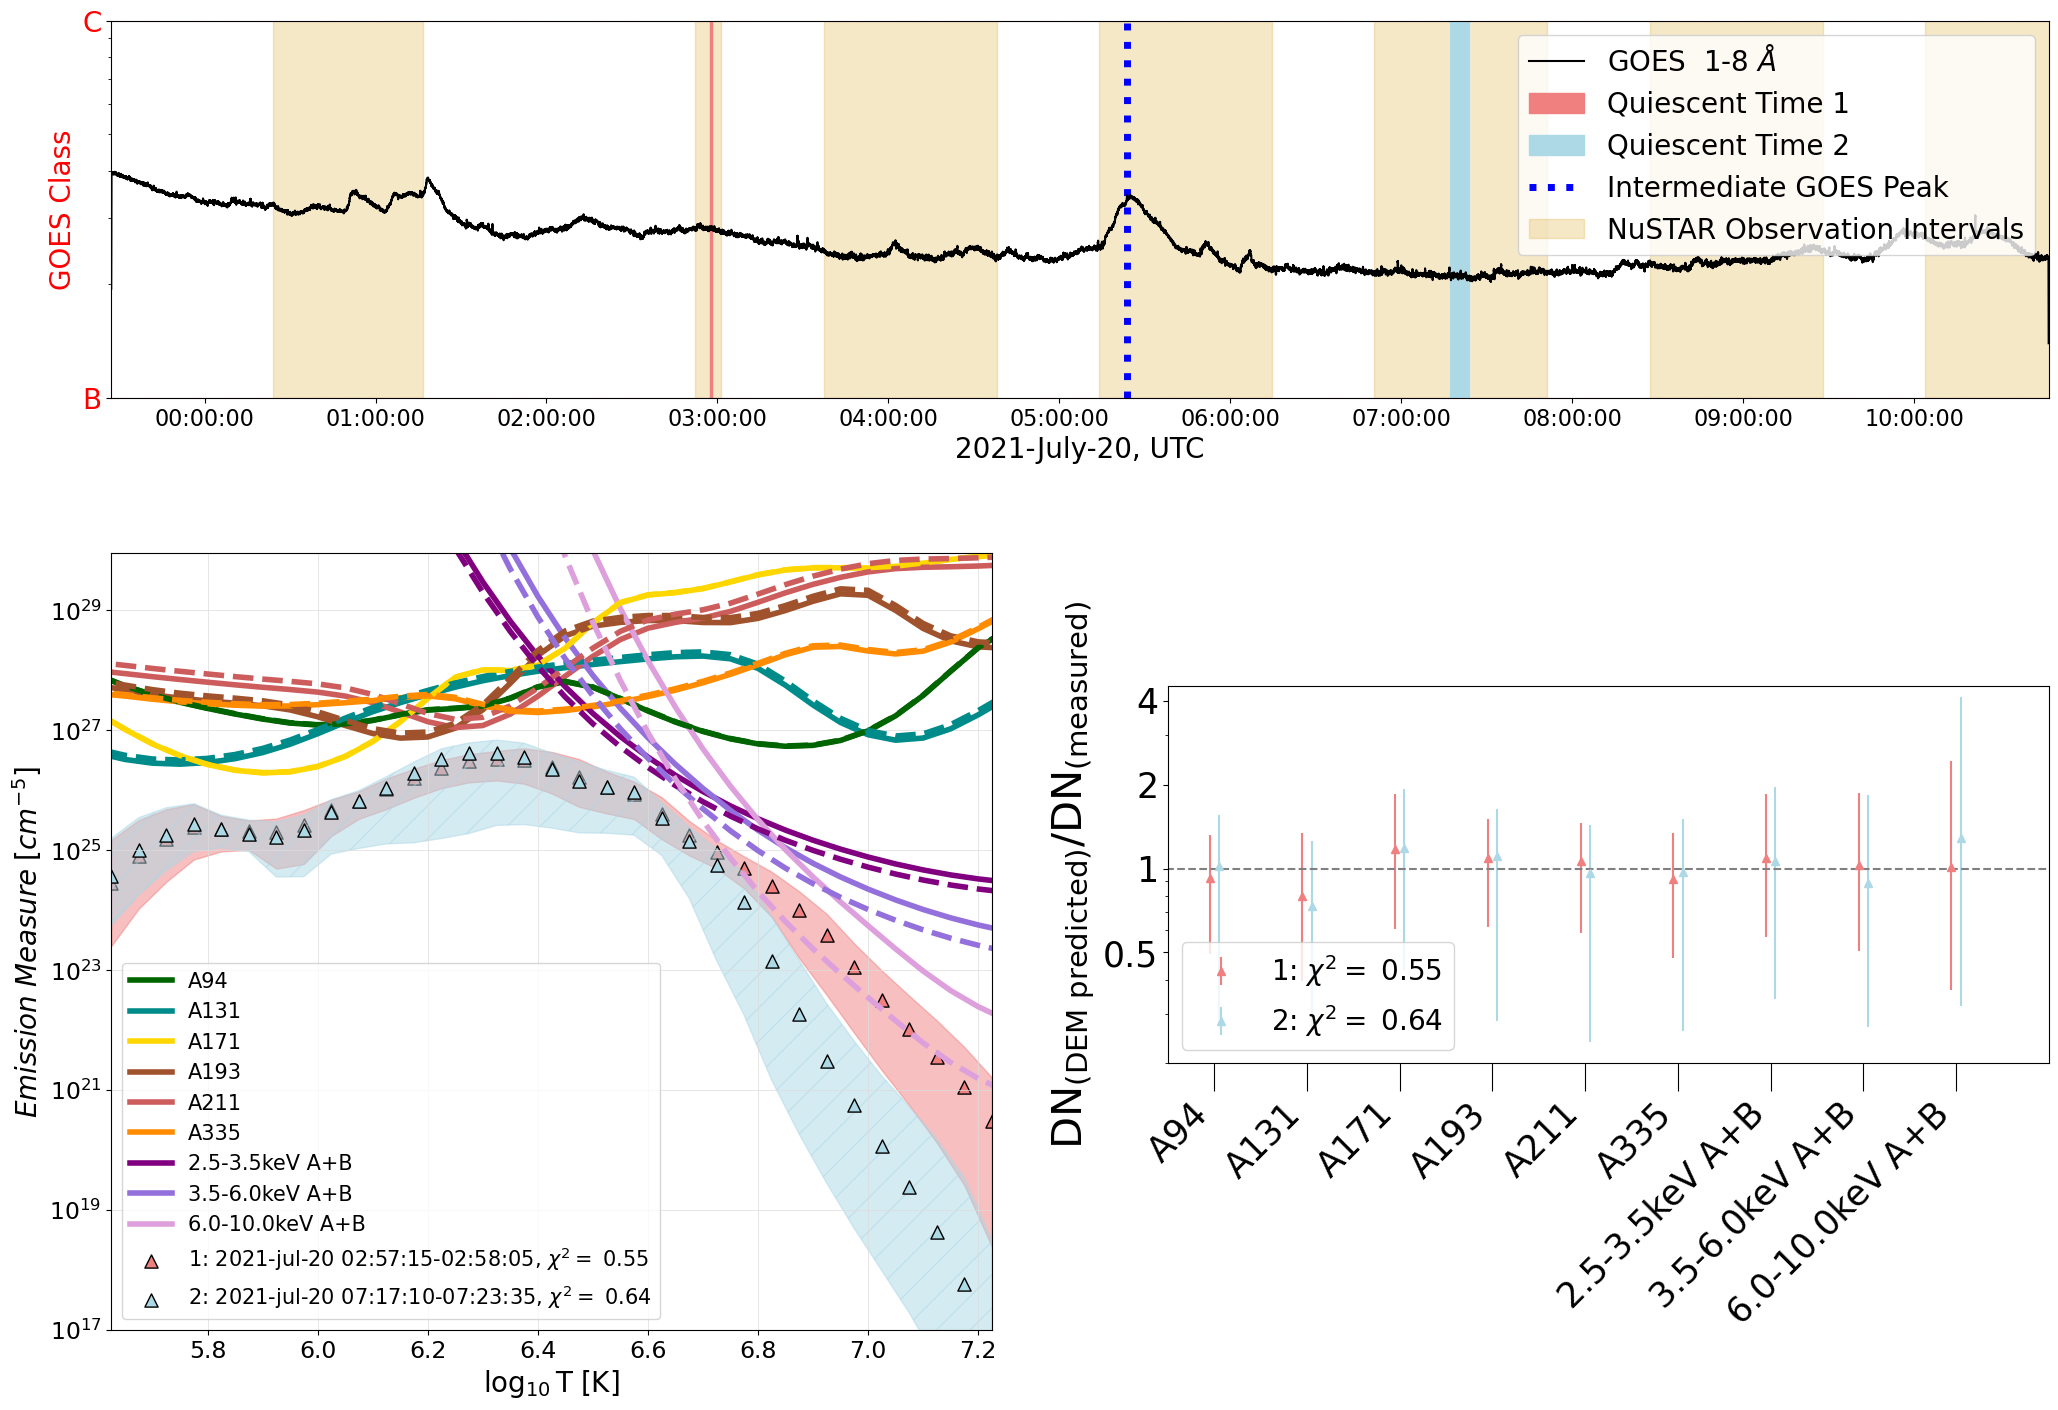

In [38]:
#jul26/27: 5
#jun06/08: 67
#sep9/10: 47
#jul20: 
which=-6

fig = plt.figure(constrained_layout=True, figsize=(25,17))
gs = fig.add_gridspec(10, 2)
ax1 = fig.add_subplot(gs[4:10, 0])
ax2 = fig.add_subplot(gs[5:8, 1])
ax3 = fig.add_subplot(gs[0:3, :])

working_dir = '/Users/jmdunca2/do-dem/consistency_plots/'

pp = incons_filepairs[which]
print(pp)
data1, timestring1, time1 = viz.load_DEM(pp[0])
data2, timestring2, time2 = viz.load_DEM(pp[1])
#namest=pp[0].split('/')[6][12:]
#namest2=pp[1].split('/')[6][12:]

namest = '2021-jul-20'
namest2 = '2021-jul-20'


#namest = '2018-sep-09'
#namest2 = '2018-sep-10'

#data1['fill_color'] = 'green'
#data2['fill_color'] = 'orange'
importlib.reload(viz)



viz.compare_DEMs(data1, data2, timestring1, timestring2, title1=namest+' '+mod_timestring(timestring1)+',', 
                                                         title2=namest2+' '+mod_timestring(timestring2)+',', 
                 plotMK=False, plot=True, working_dir=working_dir, input_ax=ax1, input_ax2=ax2)

ax1.tick_params(axis='both', labelsize=17)
#ax1.set_title('Comparison - Two Quiescent Times on '+namest, fontsize=labelfontsize)
ax1.set_title('', fontsize=labelfontsize)
ax1.legend(ncols=1, fontsize=labelfontsize*0.75)
           
#ax2.set_title('Residuals', fontsize=labelfontsize)
ax2.set_title('', fontsize=labelfontsize)
ax2.set_ylim([0.2,4.5])
ax2.set_yticks([0.5,1,2,4], ['0.5','1','2', '4'], fontsize=25)
ax2.legend(fontsize = 20, loc='lower left')


importlib.reload(lc)
from datetime import timedelta
import matplotlib.dates as mdates
labelfontsize=20


icp = incons_times[which]
axg=ax3

tr=[icp[0].datetime, icp[1].datetime]
print(tr[0].strftime('%H-%M-%S'), tr[1].strftime('%H-%M-%S'))
#from datetime import timezone
#tr = [t.replace(tzinfo=timezone.utc) for t in tr_]
goes_number = 15
if tr[0].year > 2016:
    goes_number = 16

padval=3.5
tr_pad = [tr[0]-timedelta(hours=padval), tr[1]+timedelta(hours=padval)]

#print(tr)
lc.get_goes(tr_pad, satellite=goes_number)
instrument='GOES'
gdata = lc.load_lightcurves(instrument)

ylabel = gdata['GOES flux label']
goestimes = gdata['GOES Times']
xrsbcounts = lc.boxcar_average(gdata['XRSB counts'], 10)
xrsblabel = gdata['XRSB label']
gts = [t.datetime for t in goestimes]
print('goesstep: ', gts[2]-gts[1])


#xrs=[x.value for x in all_xrsb]
axg.plot(gts, xrsbcounts, label='GOES '+xrsblabel, color='black', zorder=3)
axg.set_yscale('log')
#axg.set_ylim([1e-7,1e-6])
axg.yaxis.set_ticks([1e-7, 1e-6], labels=['B', 'C',], color='red', fontsize=labelfontsize)
axg.grid(True, which='major', axis='y', linestyle=':', color='red')

#axg.axvline(tr[0], linewidth=5, color='lightcoral', label='Quiescent Time 1')
#axg.axvline(tr[1], linewidth=5, color='lightblue', label='Quiescent Time 2')
print(time1[1])
axg.axvspan(time1[0].datetime64, time1[1].datetime64, color='lightcoral', label='Quiescent Time 1')
axg.axvspan(time2[0].datetime64, time2[1].datetime64, color='white', zorder=1)
axg.axvspan(time2[0].datetime64, time2[1].datetime64, color='lightblue', label='Quiescent Time 2', zorder=2)

axg.set_xlim([tr[0]-timedelta(hours=padval), tr[1]+timedelta(hours=padval)])
#axg.set_ylim([1e-7, 5e-6])

intergoes = np.where(np.logical_and(tr[0] < np.array(gts), np.array(gts) < tr[1]))[0]
#axg.plot(np.array(gts)[intergoes], xrsbcounts[intergoes], label='GOES '+xrsblabel, color='blue')
maxind = np.where(xrsbcounts[intergoes] == np.nanmax(xrsbcounts[intergoes]))[0]

maxval = xrsbcounts[intergoes][maxind]
if len(maxval) > 1:
    maxval=maxval[0]
maxtime = np.array(gts)[intergoes][maxind]
for m in maxtime:
    axg.axvline(m, color='blue', label='Intermediate GOES Peak', linestyle=':', linewidth=5)
#goesmax.append(maxval)
axg.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

import nustar_dem_prep as nu
keys = ['06-jun-20', '07-jun-20', '08-jun-20', '09-jun-20']
keys = ['26-jul-16_1', '27-jul-16_1']
keys = ['20-jul-21']
#keys = ['09-sep-18', '10-sep-18']
intervals = []
#with open(file, 'rb') as f:
#    all_targets = pickle.load(f)
once=0
for key in keys:
    ARDict = all_targets[key]

    id_dirs = ARDict['datapaths']

    for id in id_dirs:
        evt_data, hdr, obsid = nu.return_submap(datapath=id, fpm='A', return_evt_hdr=True, return_obsid=True)
        time0, time1 = [nuutil.convert_nustar_time(hdr['TSTART']), nuutil.convert_nustar_time(hdr['TSTOP'])]
        intervals.append([time0, time1])
        #print(timerange[0].strftime('%H-%M-%S'), timerange[1].strftime('%H-%M-%S'))
        if once == 0:
            axg.axvspan(time0.datetime64, time1.datetime64, color='goldenrod', alpha=0.25, label='NuSTAR Observation Intervals', zorder=0)
            once=1
        else:
            axg.axvspan(time0.datetime64, time1.datetime64, color='goldenrod', alpha=0.25, zorder=0)

axg.legend(fontsize=labelfontsize, loc='upper right')
axg.set_xlabel('2021-July-20, UTC', fontsize=labelfontsize)
axg.yaxis.get_offset_text().set_fontsize(labelfontsize*2)
#axg.set_ylabel(r'[$W m^{-2}$]', fontsize=labelfontsize, color='red')
axg.set_ylabel('GOES Class', fontsize=labelfontsize, color='red')

#plt.savefig('sep18_example_figure.png')
plt.savefig('jul20_example_figure.png')        
#plt.savefig('jul26-27_example_figure.png')

In [ ]:
labelfontsize=10
tbins=np.arange(-7.5,-5, 0.2)
lw=3

fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.set_title('DEM-Based Comparison', fontsize=15)
ax.hist(np.log10(goesmaxvs_fl), bins=tbins, label='No Variation', histtype='step', edgecolor='turquoise', linewidth=lw)
ax.hist(np.log10(goesmaxvs), bins=tbins, label='Variation', histtype='step', edgecolor='plum', linewidth=lw)
ax.xaxis.set_ticks([-7, -6, -5], labels=['B', 'C','M'], color='red', fontsize=labelfontsize)
ax.set_xlabel('log GOES Flux')
ax.legend()

In [ ]:
print(np.mean(goesmaxvs_fl_demcomp), np.mean(goesmaxvs_demcomp))

Next step is to check out which regions are inconsistent in the DEM method, and compare to the EM integration method. 

In [ ]:
#Make comparison plots for all the inconsistent times:

importlib.reload(viz)

working_dir = '/Users/jmdunca2/do-dem/consistency_plots/'

for pp in incons_filepairs:
    data1, timestring1, time1 = viz.load_DEM(pp[0])
    data2, timestring2, time2 = viz.load_DEM(pp[1])
    namest=pp[0].split('/')[6][11:]
    namest2=pp[1].split('/')[6][11:]
    viz.compare_DEMs(data1, data2, timestring1, timestring2, title1=namest+'-'+timestring1, title2=namest2+'-'+timestring2, plotMK=False, plot=True,
                working_dir=working_dir)

Inconsistency: lower bound of one is above the upper bound of the other.

In [ ]:
lower = np.array(dems)-np.array(edems1)
upper = np.array(dems)+np.array(edems2)
np.any(np.max(lower, axis=0) > np.min(upper, axis=0))

fig, ax = plt.subplots(1, 1, figsize=(6,3))
plt.imshow(lower, extent=[data['ts'][0], data['ts'][-1], 0, 6], aspect='auto')

fig, ax = plt.subplots(1, 1, figsize=(6,3))
plt.imshow(upper, extent=[data['ts'][0], data['ts'][-1], 0, 6], aspect='auto')


np.any(np.max(lower, axis=0) > np.min(upper, axis=0))

In [ ]:
import os

filelist = ana.get_same_region_file_lists(samesames, all_targets)

allchisq=[]
sep7chsq=[]
jan14chsq=[]
jan30chsq=[]
for fi in range(0, len(filelist)):
    ff=filelist[fi]
    ff.sort()
    for f_ in ff:
        #print(f_)
        dirp = os.path.dirname(f_)
        fill = f_.split('/')[-1]
        f_7 = dirp+'/'+('_').join(fill.split('_')[0:3])+'_7.0_'+('_').join(fill.split('_')[4:-2])+'_result.pickle'
        f_684 = dirp+'/'+('_').join(fill.split('_')[0:3])+'_6.84_'+('_').join(fill.split('_')[4:-2])+'_result.pickle'
        f_67 = dirp+'/'+('_').join(fill.split('_')[0:3])+'_6.7_'+('_').join(fill.split('_')[4:-2])+'_result.pickle'
        print(f_7)
        with open(f_67, 'rb') as f:
             data = pickle.load(f)

        allchisq.append(data['chisq'])
        #print(data.keys())
        if data['time_interval'][0].ymdhms.year == 2018 and data['time_interval'][0].ymdhms.day == 7:
            sep7chsq.append(data['chisq'])
            print(data['time_interval'][0].ymdhms)
        if data['time_interval'][0].ymdhms.year == 2021 and data['time_interval'][0].ymdhms.day == 14:
            jan14chsq.append(data['chisq'])
            print(data['time_interval'][0].ymdhms)
        if data['time_interval'][0].ymdhms.year == 2020 and data['time_interval'][0].ymdhms.day == 30:
            jan30chsq.append(data['chisq'])
            print(data['time_interval'][0].ymdhms)

print('All: ', np.mean(allchisq))
print('Sep 7: ', np.mean(sep7chsq))
print('Jan 30: ', np.mean(jan30chsq))
print('Jan 14: ', np.mean(jan14chsq))

7.0

All:  0.8069120184134211
Sep 7:  4.081292406028744
Jan 30:  1.8816126608338388
Jan 14:  1.4673193344694553

6.84
All:  1.0313475387188447 (1.03)
Sep 7:  7.003071913001397 (7.00)
Jan 30:  2.451188343385588 (2.45)
Jan 14:  1.9497130397529474 (1.95)



In [ ]:
13254-12192

In [ ]:
10**6.5/1e6
